# Disease Classification: Dengue / Chikungunya / Other
### Models: CatBoost · RandomForest · LogisticRegression · HistGradientBoosting

## 1. Imports & Setup

In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import optuna
from optuna.distributions import FloatDistribution, IntDistribution, CategoricalDistribution

from optuna_integration import OptunaSearchCV
from sklearn.metrics import make_scorer

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.neighbors import KNeighborsClassifier, RadiusNeighborsClassifier, KDTree, NearestCentroid
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, balanced_accuracy_score, roc_auc_score
)
from sklearn.utils import resample
from sklearn.utils.class_weight import compute_class_weight, compute_sample_weight
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier, PassiveAggressiveClassifier, Perceptron, SGDClassifier
from sklearn.multiclass import OneVsRestClassifier

from catboost import CatBoostClassifier

import torch
import torch.nn as nn

RANDOM_STATE = 42
print('All libraries loaded.')

All libraries loaded.


## 2. Load Data & EDA

In [2]:
recife = pd.read_csv('./recife_fin.csv')
recife.drop(columns=['race', 'hematologic_disease', 'total_symptom_burden', 'Unnamed: 0'], inplace=True)
sinan = pd.read_csv('./sinan_fin.csv')
sinan.drop(columns=['race', 'hematologic_disease', 'total_symptom_burden', 'Unnamed: 0'], inplace=True)
print('Datasets loaded.')

Datasets loaded.


#### Recife

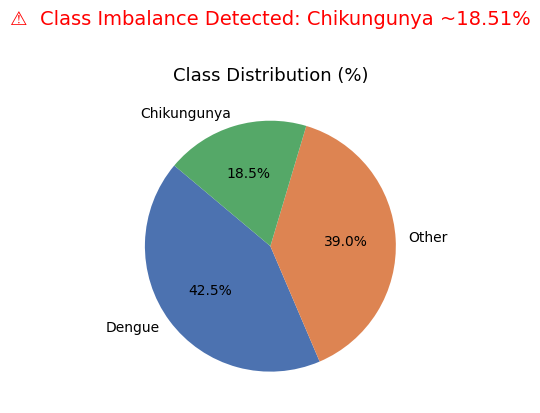

Class counts:
target
Dengue         15738
Other          14413
Chikungunya     6848
Name: count, dtype: int64

Class percentages:
target
Dengue         42.54
Other          38.96
Chikungunya    18.51
Name: count, dtype: float64


In [3]:
# Target distribution
fig, ax = plt.subplots(figsize=(12, 4))

vc_recife = recife['target'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868']
Chik_percent_recife = vc_recife.Chikungunya / (vc_recife.sum())

ax.pie(vc_recife.values, labels=vc_recife.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
ax.set_title('Class Distribution (%)', fontsize=13)

plt.suptitle(f"⚠️  Class Imbalance Detected: Chikungunya ~{(Chik_percent_recife * 100):.2f}%", fontsize=14, color='red', y=1.02)
plt.tight_layout()
plt.show()

print('Class counts:')
print(vc_recife)
print()
print('Class percentages:')
print((vc_recife / vc_recife.sum() * 100).round(2))

#### Sinan

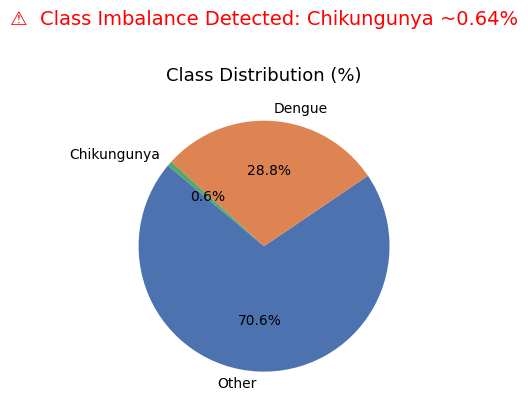

Class counts:
target
Other          27056
Dengue         11024
Chikungunya      247
Name: count, dtype: int64

Class percentages:
target
Other          70.59
Dengue         28.76
Chikungunya     0.64
Name: count, dtype: float64


In [4]:
# Target distribution
fig, ax = plt.subplots(figsize=(12, 4))

vc_sinan = sinan['target'].value_counts()
colors = ['#4C72B0', '#DD8452', '#55A868']

Chik_percent_sinan = vc_sinan.Chikungunya / (vc_sinan.sum())

ax.pie(vc_sinan.values, labels=vc_sinan.index, autopct='%1.1f%%',
            colors=colors, startangle=140)
ax.set_title('Class Distribution (%)', fontsize=13)

plt.suptitle(f"⚠️  Class Imbalance Detected: Chikungunya ~{(Chik_percent_sinan * 100):.2f}%", fontsize=14, color='red', y=1.02)
plt.tight_layout()
plt.show()

print('Class counts:')
print(vc_sinan)
print()
print('Class percentages:')
print((vc_sinan / vc_sinan.sum() * 100).round(2))

Columns with missing values: 7


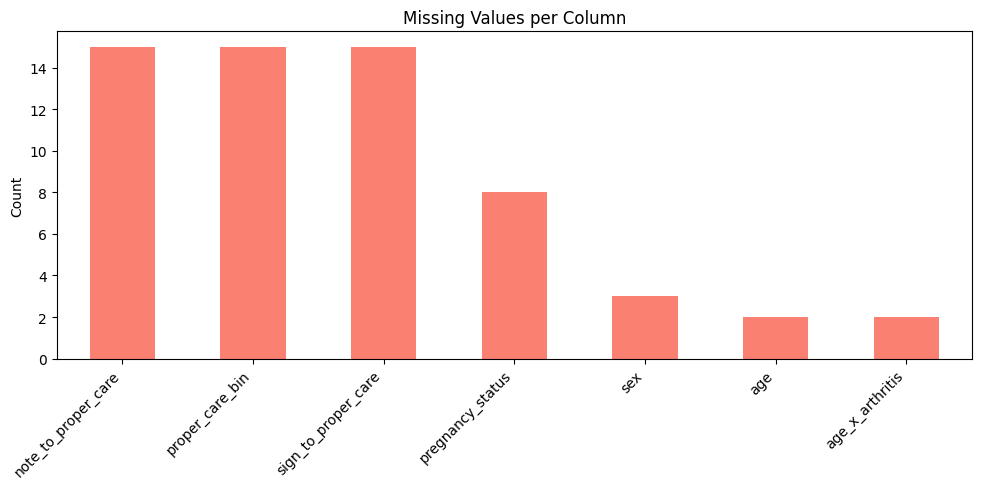

In [5]:
# Missing values heatmap
missing = recife.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print(f'Columns with missing values: {len(missing)}')

plt.figure(figsize=(10, 5))
missing.plot(kind='bar', color='salmon')
plt.title('Missing Values per Column')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Preprocessing

#### Recife alone

In [6]:
# Drop rows with missing target
recife = recife.dropna(subset=['target']).copy()
print(f'After dropping missing targets: {recife.shape}')

# Separate features and target. target_with_severity is a label-derived column,
# so keeping it in X leaks the answer and makes CV scores meaningless.
X = recife.drop(columns=['target', 'target_with_severity'], errors='ignore')
y = recife['target']

leaky_cols = [c for c in X.columns if any(token in c.lower() for token in ['target', 'severity', 'classi_fin'])]
assert not leaky_cols, f'Leakage columns still present in X: {leaky_cols}'

# Identify column types
cat_cols = X.select_dtypes(include=['object', 'string']).columns.tolist()
num_cols = X.select_dtypes(include=['number']).columns.tolist()

print(f'Categorical columns ({len(cat_cols)}): {cat_cols}')
print(f'Numeric columns ({len(num_cols)}): {len(num_cols)} features')
print('Feature matrix is leakage-safe:', X.shape)

After dropping missing targets: (36999, 62)
Categorical columns (4): ['sex', 'pregnancy_status', 'note_bin', 'proper_care_bin']
Numeric columns (55): 55 features
Feature matrix is leakage-safe: (36999, 60)


In [7]:
# Encode target
le = LabelEncoder()
y_enc = le.fit_transform(y)
print('Classes:', le.classes_)

# Train/test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_enc
)
print(f'Train size: {X_train.shape}, Test size: {X_test.shape}')

Classes: ['Chikungunya' 'Dengue' 'Other']
Train size: (29599, 60), Test size: (7400, 60)


In [8]:
# Helper: evaluate and visualize a fitted model
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te, classes):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    bal_acc = balanced_accuracy_score(y_te, y_pred)
    macro_f1 = f1_score(y_te, y_pred, average='macro')

    print('\n' + '=' * 55)
    print(f'  {name}')
    print('=' * 55)
    print(f'  Balanced Accuracy : {bal_acc:.4f}')
    print(f'  Macro F1          : {macro_f1:.4f}')
    print()
    print(classification_report(y_te, y_pred, target_names=classes))

    cm = confusion_matrix(y_te, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
    fig, ax = plt.subplots(figsize=(6, 5))
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nBalanced Acc: {bal_acc:.3f} | Macro F1: {macro_f1:.3f}', fontsize=11)
    plt.tight_layout()
    plt.show()

    return {'model': name, 'balanced_acc': bal_acc, 'macro_f1': macro_f1}

results = []
print('Helper ready.')


Helper ready.


#### Concat

In [9]:
sinan = sinan.dropna(subset=["target"]).copy()
df = pd.concat([sinan, recife], ignore_index=True)
df = df.dropna(subset=['target']).copy()
print(f"After dropping missing targets: {df.shape}")

Xcc = df.drop(columns=['target', 'target_with_severity'], errors='ignore')
ycc = df['target']

After dropping missing targets: (75326, 62)


In [10]:
# Encode target
lecc = LabelEncoder()
ycc_enc = lecc.fit_transform(ycc)
print('Classes:', lecc.classes_)

# Train/test split (stratified)
Xcc_train, Xcc_test, ycc_train, ycc_test = train_test_split(
    Xcc, ycc_enc, test_size=0.2, random_state=RANDOM_STATE, stratify=ycc_enc
)
print(f'Train size: {Xcc_train.shape}, Test size: {Xcc_test.shape}')

Classes: ['Chikungunya' 'Dengue' 'Other']
Train size: (60260, 60), Test size: (15066, 60)


In [11]:
train_df = Xcc_train.copy()
train_df["target"] = ycc_train
counts = train_df["target"].value_counts()
target_n = counts.min() # balance to minority size
balanced_parts = []
for cls, group in train_df.groupby("target"):
    if len(group) > target_n:
        group_down = resample(
            group,
            replace=False,
            n_samples=target_n,
            random_state=RANDOM_STATE
        )
    else:
        group_down = group
    balanced_parts.append(group_down)

train_bal = pd.concat(balanced_parts).sample(frac=1, random_state=RANDOM_STATE)

Xcc_train = train_bal.drop(columns=["target"])
ycc_train = train_bal["target"].to_numpy()

In [12]:
results_cc = []
print("Concat_ready")

Concat_ready


## Model singularity + OptunaSearchCV

In [13]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
f1_macro = make_scorer(f1_score, average='macro')

## 4. Model 1 — CatBoost
Handles categoricals natively and supports `class_weights` for imbalance.

#### Recife

[I 2026-06-08 17:35:23,456] A new study created in memory with name: no-name-590d8905-2f0c-4aba-b16b-3477320206dc


CatBoost class weights: {0: 1.800754395570968, 1: 0.78366428382314, 2: 0.8557097427002024}


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-06-08 17:36:02,618] Trial 0 finished with value: 0.5910544234675755 and parameters: {'iterations': 600, 'learning_rate': 0.2536999076681772, 'depth': 9, 'l2_leaf_reg': 0.9466503798478175, 'random_strength': 0.004207988669606638, 'border_count': 66}. Best is trial 0 with value: 0.5910544234675755.
[I 2026-06-08 17:36:53,083] Trial 1 finished with value: 0.5944083470061106 and parameters: {'iterations': 400, 'learning_rate': 0.19030368381735815, 'depth': 8, 'l2_leaf_reg': 2.1745470981373622, 'random_strength': 0.0012087541473056963, 'border_count': 244}. Best is trial 1 with value: 0.5944083470061106.
[I 2026-06-08 17:38:25,298] Trial 2 finished with value: 0.5781295322410666 and parameters: {'iterations': 900, 'learning_rate': 0.020589728197687916, 'depth': 5, 'l2_leaf_reg': 0.040311020093778335, 'random_strength': 0.016480446427978974, 'border_count': 146}. Best is trial 1 with value: 0.5944083470061106.
[I 2026-06-08 17:40:14,663] Trial 3 finished with value: 0.594473268726399

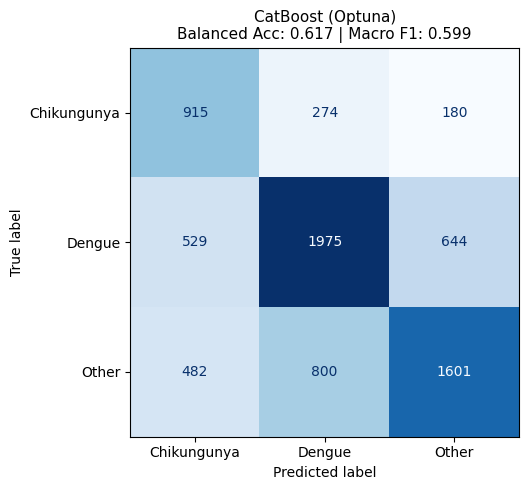

In [14]:
X_train_cb = X_train.copy()
X_test_cb = X_test.copy()

classes = np.unique(y_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=y_train)
class_weights = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
print('CatBoost class weights:', class_weights)

# Impute numerics
for col in num_cols:
    med = X_train_cb[col].median()
    X_train_cb[col] = X_train_cb[col].fillna(med)
    X_test_cb[col] = X_test_cb[col].fillna(med)

# Impute categoricals
for col in cat_cols:
    m = X_train_cb[col].mode(dropna=True)
    mode = m.iloc[0] if not m.empty else 'Missing'
    X_train_cb[col] = X_train_cb[col].fillna(mode).astype(str)
    X_test_cb[col] = X_test_cb[col].fillna(mode).astype(str)

cat_features = cat_cols
cb_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def make_catboost(params):
    return CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='TotalF1',
        random_seed=RANDOM_STATE,
        verbose=0,
        class_weights=class_weights,
        allow_writing_files=False,
        **params
    )

def cb_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 400, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 20.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 250),
    }

    scores = []
    for train_idx, valid_idx in cb_cv.split(X_train_cb, y_train):
        model = make_catboost(params)
        model.fit(
            X_train_cb.iloc[train_idx],
            y_train[train_idx],
            cat_features=cat_features,
            eval_set=(X_train_cb.iloc[valid_idx], y_train[valid_idx]),
            early_stopping_rounds=30,
            verbose=0,
        )
        pred = model.predict(X_train_cb.iloc[valid_idx]).reshape(-1)
        scores.append(f1_score(y_train[valid_idx], pred, average='macro'))
    return float(np.mean(scores))

cb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
cb_study.optimize(cb_objective, n_trials=15, show_progress_bar=True)

print('CatBoost best score:', cb_study.best_value)
print('CatBoost best params:', cb_study.best_params)

catboost_best = make_catboost(cb_study.best_params)
catboost_best.fit(
    X_train_cb,
    y_train,
    cat_features=cat_features,
    verbose=0,
)

y_pred = catboost_best.predict(X_test_cb).reshape(-1)
bal_acc = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average='macro')

print('\n' + '=' * 55)
print('  CatBoost (Optuna)')
print('=' * 55)
print(f'  Balanced Accuracy : {bal_acc:.4f}')
print(f'  Macro F1          : {macro_f1:.4f}')
print()
print(classification_report(y_test, y_pred, target_names=le.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'CatBoost (Optuna)\nBalanced Acc: {bal_acc:.3f} | Macro F1: {macro_f1:.3f}', fontsize=11)
plt.tight_layout()
plt.show()

results.append({'model': 'CatBoost (Optuna)', 'balanced_acc': bal_acc, 'macro_f1': macro_f1})

CatBoost best score: 0.5969340223003107

CatBoost best params: {'iterations': 500, 'learning_rate': 0.08995147228189702, 'depth': 8, 'l2_leaf_reg': 4.2403143657545375, 'random_strength': 0.07495849797769727, 'border_count': 182}

=======================================================
  CatBoost (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.6145
  Macro F1          : 0.5954

              precision    recall  f1-score   support
...
    accuracy                           0.60      7400
   macro avg       0.59      0.61      0.60      7400
weighted avg       0.62      0.60      0.61      7400
```

In [15]:
# Preprocessor for sklearn models (RF, LR, HGB)
# Numeric: median impute
# Categorical: most_frequent impute + label encode (ordinal)
from sklearn.preprocessing import OrdinalEncoder

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

preprocessor = ColumnTransformer([
    ('num', numeric_transformer, num_cols),
    ('cat', categorical_transformer, cat_cols)
])

print('Preprocessor ready.')

Preprocessor ready.


#### Concat

CatBoost class weights: {0: 1.0, 1: 1.0, 2: 1.0}


[I 2026-06-08 17:51:51,001] A new study created in memory with name: no-name-f7e5ec84-6d31-4c1a-af1b-4682d85a9c57


  0%|          | 0/15 [00:00<?, ?it/s]

[I 2026-06-08 17:52:17,351] Trial 0 finished with value: 0.6640432101466945 and parameters: {'iterations': 600, 'learning_rate': 0.2536999076681772, 'depth': 9, 'l2_leaf_reg': 0.9466503798478175, 'random_strength': 0.004207988669606638, 'border_count': 66}. Best is trial 0 with value: 0.6640432101466945.
[I 2026-06-08 17:52:48,426] Trial 1 finished with value: 0.6671742600044093 and parameters: {'iterations': 400, 'learning_rate': 0.19030368381735815, 'depth': 8, 'l2_leaf_reg': 2.1745470981373622, 'random_strength': 0.0012087541473056963, 'border_count': 244}. Best is trial 1 with value: 0.6671742600044093.
[I 2026-06-08 17:53:23,298] Trial 2 finished with value: 0.6514868058040851 and parameters: {'iterations': 900, 'learning_rate': 0.020589728197687916, 'depth': 5, 'l2_leaf_reg': 0.040311020093778335, 'random_strength': 0.016480446427978974, 'border_count': 146}. Best is trial 1 with value: 0.6671742600044093.
[I 2026-06-08 17:53:58,380] Trial 3 finished with value: 0.658278799216062

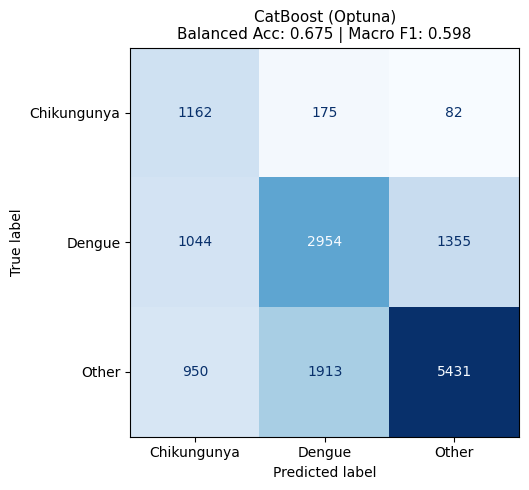

In [16]:
Xcc_train_cb = Xcc_train.copy()
Xcc_test_cb = Xcc_test.copy()

classes = np.unique(ycc_train)
weights = compute_class_weight(class_weight='balanced', classes=classes, y=ycc_train)
class_weights = {int(cls): float(weight) for cls, weight in zip(classes, weights)}
print('CatBoost class weights:', class_weights)

# Impute numerics
for col in num_cols:
    med = Xcc_train_cb[col].median()
    Xcc_train_cb[col] = Xcc_train_cb[col].fillna(med)
    Xcc_test_cb[col] = Xcc_test_cb[col].fillna(med)

# Impute categoricals
for col in cat_cols:
    m = Xcc_train_cb[col].mode(dropna=True)
    mode = m.iloc[0] if not m.empty else 'Missing'
    Xcc_train_cb[col] = Xcc_train_cb[col].fillna(mode).astype(str)
    Xcc_test_cb[col] = Xcc_test_cb[col].fillna(mode).astype(str)

cat_features = cat_cols
cb_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

def make_catboost(params):
    return CatBoostClassifier(
        loss_function='MultiClass',
        eval_metric='TotalF1',
        random_seed=RANDOM_STATE,
        verbose=0,
        class_weights=class_weights,
        allow_writing_files=False,
        **params
    )

def cb_objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 400, 1000, step=100),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1e-2, 20.0, log=True),
        'random_strength': trial.suggest_float('random_strength', 1e-3, 10.0, log=True),
        'border_count': trial.suggest_int('border_count', 32, 250),
    }

    scores = []
    for train_idx, valid_idx in cb_cv.split(Xcc_train_cb, ycc_train):
        model = make_catboost(params)
        model.fit(
            Xcc_train_cb.iloc[train_idx],
            ycc_train[train_idx],
            cat_features=cat_features,
            eval_set=(Xcc_train_cb.iloc[valid_idx], ycc_train[valid_idx]),
            early_stopping_rounds=30,
            verbose=0,
        )
        pred = model.predict(Xcc_train_cb.iloc[valid_idx]).reshape(-1)
        scores.append(f1_score(ycc_train[valid_idx], pred, average='macro'))
    return float(np.mean(scores))

cb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE)
)
cb_study.optimize(cb_objective, n_trials=15, show_progress_bar=True)

print('CatBoost best score:', cb_study.best_value)
print('CatBoost best params:', cb_study.best_params)

catboost_best = make_catboost(cb_study.best_params)
catboost_best.fit(
    Xcc_train_cb,
    ycc_train,
    cat_features=cat_features,
    verbose=0,
)

ycc_pred = catboost_best.predict(Xcc_test_cb).reshape(-1)
bal_acc = balanced_accuracy_score(ycc_test, ycc_pred)
macro_f1 = f1_score(ycc_test, ycc_pred, average='macro')

print('\n' + '=' * 55)
print('  CatBoost (Optuna)')
print('=' * 55)
print(f'  Balanced Accuracy : {bal_acc:.4f}')
print(f'  Macro F1          : {macro_f1:.4f}')
print()
print(classification_report(ycc_test, ycc_pred, target_names=le.classes_))

cm = confusion_matrix(ycc_test, ycc_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le.classes_)
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title(f'CatBoost (Optuna)\nBalanced Acc: {bal_acc:.3f} | Macro F1: {macro_f1:.3f}', fontsize=11)
plt.tight_layout()
plt.show()

results.append({'model': 'CatBoost (Optuna)', 'balanced_acc': bal_acc, 'macro_f1': macro_f1})

## 5. Model 2 — Random Forest
Uses `class_weight='balanced_subsample'` to address imbalance at each bootstrap.

[I 2026-06-08 18:01:49,744] A new study created in memory with name: no-name-54687052-b5c4-4b3a-a573-943061b0ab82
[I 2026-06-08 18:02:01,736] Trial 0 finished with value: 0.5986412200897528 and parameters: {'classifier__n_estimators': 850, 'classifier__max_depth': 19, 'classifier__min_samples_split': 9, 'classifier__min_samples_leaf': 3, 'classifier__max_features': 'sqrt', 'classifier__class_weight': None, 'classifier__criterion': 'entropy'}. Best is trial 0 with value: 0.5986412200897528.
[I 2026-06-08 18:02:11,529] Trial 1 finished with value: 0.5935238754880737 and parameters: {'classifier__n_estimators': 850, 'classifier__max_depth': 15, 'classifier__min_samples_split': 12, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini'}. Best is trial 0 with value: 0.5986412200897528.
[I 2026-06-08 18:02:20,847] Trial 2 finished with value: 0.5941000547278973 and parameters: {'classifier__n_estimators':

RF best score: 0.6013624002439908
RF best params: {'classifier__n_estimators': 950, 'classifier__max_depth': 20, 'classifier__min_samples_split': 12, 'classifier__min_samples_leaf': 3, 'classifier__max_features': None, 'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini'}

  Random Forest (Optuna)
  Balanced Accuracy : 0.6138
  Macro F1          : 0.6007

              precision    recall  f1-score   support

 Chikungunya       0.49      0.63      0.55      1369
      Dengue       0.64      0.65      0.65      3148
       Other       0.65      0.56      0.60      2883

    accuracy                           0.61      7400
   macro avg       0.60      0.61      0.60      7400
weighted avg       0.62      0.61      0.61      7400



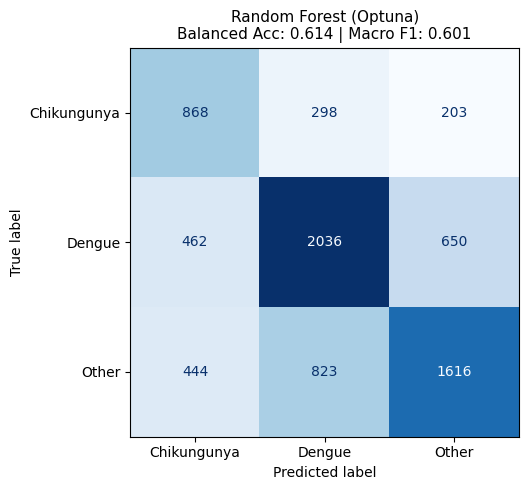

In [17]:
# RandomForest tuning can become very slow with 10 trials * 5 folds * hundreds of trees.
# Use a lighter RF-specific CV/search budget so this cell finishes reliably in a notebook.
X_train_rf, X_test_rf = X_train.copy(), X_test.copy()
rf_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

rf_param = {
    'classifier__n_estimators': IntDistribution(700, 1000, step=50),
    'classifier__max_depth': IntDistribution(14, 20),
    'classifier__min_samples_split': IntDistribution(9, 16),
    'classifier__min_samples_leaf': IntDistribution(2, 6),
    'classifier__max_features': CategoricalDistribution(['sqrt', 'log2', None]),
    'classifier__class_weight': CategoricalDistribution(['balanced', 'balanced_subsample', None]),
    'classifier__criterion': CategoricalDistribution(['gini', 'entropy'])
}

rf_search = OptunaSearchCV(
    estimator=rf_pipeline,
    param_distributions=rf_param,
    cv=rf_cv,
    scoring=f1_macro,
    n_trials=10,
    random_state=RANDOM_STATE,
    n_jobs=1,  # RF itself uses all cores; do not parallelize trials/folds too.
    verbose=1,
    refit=True
)

rf_search.fit(X_train, y_train)
print('RF best score:', rf_search.best_score_)
print('RF best params:', rf_search.best_params_)

rf_best = rf_search.best_estimator_

res = evaluate_model(
    'Random Forest (Optuna)',
    rf_best,
    X_train_rf, y_train,
    X_test_rf, y_test,
    le.classes_
)
results.append(res)

#### Eval
RF best score: 0.6013624002439908
RF best params: {'classifier__n_estimators': 950, 'classifier__max_depth': 20, 'classifier__min_samples_split': 12, 'classifier__min_samples_leaf': 3, 'classifier__max_features': None, 'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini'}

#### Concat

[I 2026-06-08 18:04:32,635] A new study created in memory with name: no-name-bb3d8e97-4a12-4a5a-8583-326b1f95a387
[I 2026-06-08 18:04:38,816] Trial 0 finished with value: 0.6532808977418413 and parameters: {'classifier__n_estimators': 600, 'classifier__max_depth': 19, 'classifier__min_samples_split': 9, 'classifier__min_samples_leaf': 3, 'classifier__max_features': 'sqrt', 'classifier__class_weight': None, 'classifier__criterion': 'entropy'}. Best is trial 0 with value: 0.6532808977418413.
[I 2026-06-08 18:04:45,068] Trial 1 finished with value: 0.6491307148612412 and parameters: {'classifier__n_estimators': 600, 'classifier__max_depth': 15, 'classifier__min_samples_split': 12, 'classifier__min_samples_leaf': 4, 'classifier__max_features': 'log2', 'classifier__class_weight': 'balanced', 'classifier__criterion': 'gini'}. Best is trial 0 with value: 0.6532808977418413.
[I 2026-06-08 18:04:51,149] Trial 2 finished with value: 0.6502217751491631 and parameters: {'classifier__n_estimators':

RF best score: 0.6545721906030714
RF best params: {'classifier__n_estimators': 1000, 'classifier__max_depth': 17, 'classifier__min_samples_split': 16, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__class_weight': 'balanced_subsample', 'classifier__criterion': 'entropy'}

  Random Forest (Optuna)
  Balanced Accuracy : 0.6635
  Macro F1          : 0.5794

              precision    recall  f1-score   support

 Chikungunya       0.34      0.82      0.48      1419
      Dengue       0.58      0.54      0.56      5353
       Other       0.79      0.63      0.70      8294

    accuracy                           0.62     15066
   macro avg       0.57      0.66      0.58     15066
weighted avg       0.67      0.62      0.63     15066



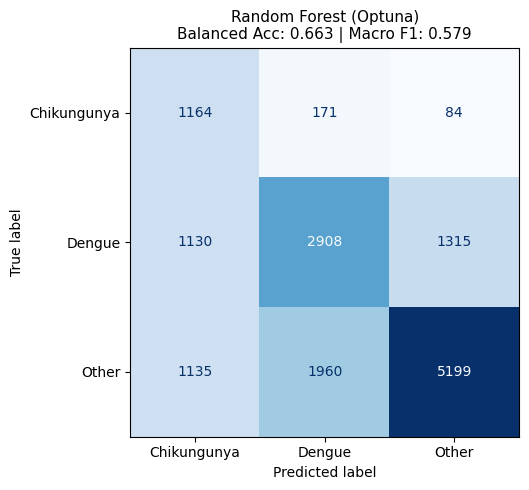

In [18]:
# RandomForest tuning can become very slow with 10 trials * 5 folds * hundreds of trees.
# Use a lighter RF-specific CV/search budget so this cell finishes reliably in a notebook.
Xcc_train_rf, Xcc_test_rf = Xcc_train.copy(), Xcc_test.copy()
rf_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_jobs=-1,
        random_state=RANDOM_STATE
    ))
])

ccrf_param = {
    'classifier__n_estimators': IntDistribution(200, 1000, step=100),
    'classifier__max_depth': IntDistribution(14, 20),
    'classifier__min_samples_split': IntDistribution(9, 16),
    'classifier__min_samples_leaf': IntDistribution(2, 6),
    'classifier__max_features': CategoricalDistribution(['sqrt', 'log2', None]),
    'classifier__class_weight': CategoricalDistribution(['balanced', 'balanced_subsample', None]),
    'classifier__criterion': CategoricalDistribution(['gini', 'entropy'])
}

ccrf_search = OptunaSearchCV(
    estimator=rf_pipeline,
    param_distributions=ccrf_param,
    cv=rf_cv,
    scoring=f1_macro,
    n_trials=20,
    random_state=RANDOM_STATE,
    n_jobs=1,  # RF itself uses all cores; do not parallelize trials/folds too.
    verbose=1,
    refit=True
)

ccrf_search.fit(Xcc_train, ycc_train)
print('RF best score:', ccrf_search.best_score_)
print('RF best params:', ccrf_search.best_params_)

rf_best = ccrf_search.best_estimator_

res = evaluate_model(
    'Random Forest (Optuna)',
    rf_best,
    Xcc_train_rf, ycc_train,
    Xcc_test_rf, ycc_test,
    le.classes_
)
results.append(res)

RF best score: 0.6545721906030714
RF best params: {'classifier__n_estimators': 1000, 'classifier__max_depth': 17, 'classifier__min_samples_split': 16, 'classifier__min_samples_leaf': 2, 'classifier__max_features': 'sqrt', 'classifier__class_weight': 'balanced_subsample', 'classifier__criterion': 'entropy'}

## Model 3 - Linear models

### Logistic Regression

#### Recife

LR Train: (29576, 60)  |  LR Test: (7395, 60)

[I 2026-06-08 18:08:47,394] A new study created in memory with name: no-name-aec26ee3-239b-4171-9a54-3eb867916786


[I 2026-06-08 18:08:50,479] Trial 9 finished with value: 0.5269481861338315 and parameters: {'classifier__C': 0.001295757957456768, 'classifier__fit_intercept': False, 'classifier__class_weight': 'balanced', 'classifier__tol': 0.007342340882157576, 'classifier__l1_ratio': 0}. Best is trial 9 with value: 0.5269481861338315.
[I 2026-06-08 18:08:58,514] Trial 12 finished with value: 0.5444497824841397 and parameters: {'classifier__C': 0.015985368963122165, 'classifier__fit_intercept': True, 'classifier__class_weight': None, 'classifier__tol': 0.0014351828202923032, 'classifier__l1_ratio': 0}. Best is trial 12 with value: 0.5444497824841397.
[I 2026-06-08 18:09:01,734] Trial 2 finished with value: 0.5426301524144506 and parameters: {'classifier__C': 0.041533514267040085, 'classifier__fit_intercept': False, 'classifier__class_weight': None, 'classifier__tol': 0.00681242073640647, 'classifier__l1_ratio': 0.5}. Best is trial 12 with value: 0.5444497824841397.
[I 2026-06-08 18:09:05,155] Trial

LR best score: 0.5451318028540815
LR best params: {'classifier__C': 6.370786755297201, 'classifier__fit_intercept': True, 'classifier__class_weight': None, 'classifier__tol': 0.0009732854643099765, 'classifier__l1_ratio': 0}

  Logistic Regression (Optuna)
  Balanced Accuracy : 0.5411
  Macro F1          : 0.5451

              precision    recall  f1-score   support

 Chikungunya       0.51      0.45      0.48      1370
      Dengue       0.55      0.66      0.60      3147
       Other       0.60      0.51      0.55      2878

    accuracy                           0.56      7395
   macro avg       0.56      0.54      0.55      7395
weighted avg       0.57      0.56      0.56      7395



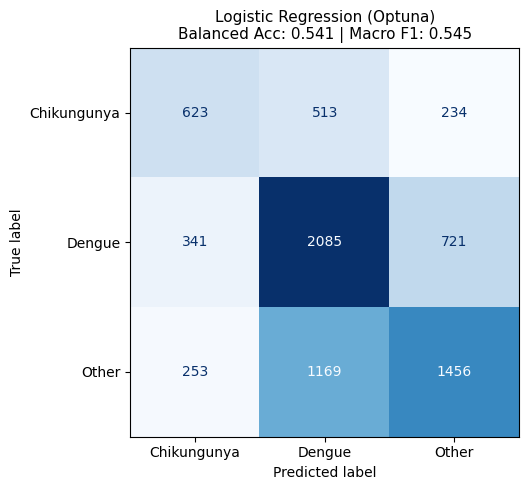

In [19]:
# --- Drop ALL rows that contain any missing value ---
recife_lr = recife.dropna()
X_lr = recife_lr.drop(columns=['target', 'target_with_severity'], errors='ignore')
y_lr = le.transform(recife_lr['target'])   # reuse fitted LabelEncoder

# Stratified split on the clean subset
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=RANDOM_STATE, stratify=y_lr
)
print(f'LR Train: {X_train_lr.shape}  |  LR Test: {X_test_lr.shape}')

# Preprocessor with NO imputer (data is already clean)
from sklearn.preprocessing import OrdinalEncoder

lr_cat_cols = X_lr.select_dtypes(include=['object', 'string']).columns.tolist()
lr_num_cols = X_lr.select_dtypes(include=['number']).columns.tolist()

lr_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), lr_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), lr_cat_cols)
])

lr_pipeline = Pipeline([
    ('preprocessor', lr_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=3000,
        random_state=RANDOM_STATE,
        solver="saga",
    ))
])

lr_param = {
    "classifier__C": FloatDistribution(1e-3, 20.0, log=True),
    # "classifier__solver": CategoricalDistribution(["lbfgs", "liblinear", "saga"]),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__class_weight": CategoricalDistribution([None, "balanced"]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__l1_ratio": CategoricalDistribution([0, 0.5, 1]),
}

lr_search = OptunaSearchCV(
    estimator=lr_pipeline,
    param_distributions=lr_param,
    cv=cv,
    scoring="f1_macro",
    n_trials=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

lr_search.fit(X_train_lr, y_train_lr)

print("LR best score:", lr_search.best_score_)
print("LR best params:", lr_search.best_params_)

lr_best = lr_search.best_estimator_

res = evaluate_model(
    "Logistic Regression (Optuna)",
    lr_best,
    X_train_lr, y_train_lr,
    X_test_lr, y_test_lr,
    le.classes_
)
results_cc.append(res)

LR best score: 0.5451318028540815
LR best params: {'classifier__C': 6.370786755297201, 'classifier__fit_intercept': True, 'classifier__class_weight': None, 'classifier__tol': 0.0009732854643099765, 'classifier__l1_ratio': 0}

=======================================================
  Logistic Regression (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5411
  Macro F1          : 0.5451

              precision    recall  f1-score   support

 Chikungunya       0.51      0.45      0.48      1370
      Dengue       0.55      0.66      0.60      3147
       Other       0.60      0.51      0.55      2878

    accuracy                           0.56      7395
   macro avg       0.56      0.54      0.55      7395
weighted avg       0.57      0.56      0.56      7395
```

#### Concat

[I 2026-06-08 18:12:19,932] A new study created in memory with name: no-name-813c7317-4616-47f1-b100-10b4772ed529


LR Train: (10731, 60)  |  LR Test: (7372, 60)


[I 2026-06-08 18:12:21,751] Trial 2 finished with value: 0.5622700561961109 and parameters: {'classifier__C': 0.0022266020729991755, 'classifier__fit_intercept': False, 'classifier__class_weight': 'balanced', 'classifier__tol': 0.00027055516183291736, 'classifier__l1_ratio': 0}. Best is trial 2 with value: 0.5622700561961109.
[I 2026-06-08 18:12:21,882] Trial 15 finished with value: 0.5434582110093521 and parameters: {'classifier__C': 0.0033748195809613236, 'classifier__fit_intercept': False, 'classifier__class_weight': None, 'classifier__tol': 0.0028596640445556583, 'classifier__l1_ratio': 1}. Best is trial 2 with value: 0.5622700561961109.
[I 2026-06-08 18:12:22,873] Trial 16 finished with value: 0.5621396527345038 and parameters: {'classifier__C': 0.0016090402585165592, 'classifier__fit_intercept': False, 'classifier__class_weight': 'balanced', 'classifier__tol': 0.004075757537459235, 'classifier__l1_ratio': 0}. Best is trial 2 with value: 0.5622700561961109.
[I 2026-06-08 18:12:23,

LR best score: 0.5659859601779118
LR best params: {'classifier__C': 0.1175150416850473, 'classifier__fit_intercept': True, 'classifier__class_weight': 'balanced', 'classifier__tol': 0.0007125726805535352, 'classifier__l1_ratio': 0.5}

  LR (saga) (Optuna)
  Balanced Accuracy : 0.5676
  Macro F1          : 0.5304

              precision    recall  f1-score   support

 Chikungunya       0.39      0.73      0.51      1376
      Dengue       0.59      0.49      0.53      3141
       Other       0.62      0.49      0.55      2855

    accuracy                           0.53      7372
   macro avg       0.54      0.57      0.53      7372
weighted avg       0.57      0.53      0.53      7372



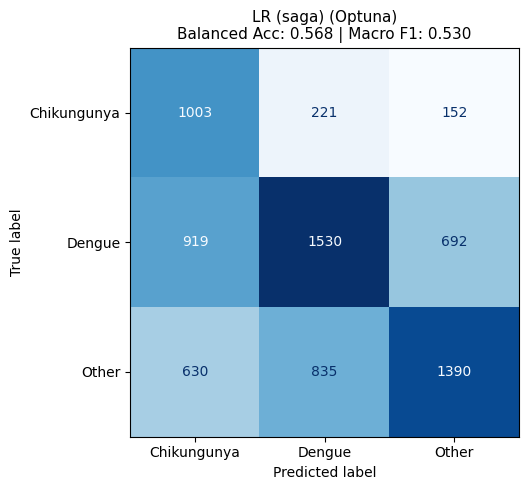

In [20]:
# --- Drop ALL rows that contain any missing value ---

# Stratified split on the clean subset
cc_train2 = Xcc_train.copy()
cc_train2["target"] = ycc_train
cc_test2 = Xcc_test.copy()
cc_test2["target"] = ycc_test
cc_train2.dropna(inplace=True)
cc_test2.dropna(inplace=True)
Xcc_lr = pd.concat([cc_train2, cc_test2], ignore_index=True).drop(columns=["target"])

Xcc_train_lr, Xcc_test_lr, ycc_train_lr, ycc_test_lr = cc_train2.drop(columns=["target"]), cc_test2.drop(columns=["target"]), cc_train2["target"], cc_test2["target"]
print(f'LR Train: {Xcc_train_lr.shape}  |  LR Test: {Xcc_test_lr.shape}')

lr_cat_cols = Xcc_lr.select_dtypes(include=['object', 'string']).columns.tolist()
lr_num_cols = Xcc_lr.select_dtypes(include=['number']).columns.tolist()

cc_lr_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), lr_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), lr_cat_cols)
])

cclr_pipeline = Pipeline([
    ('preprocessor', cc_lr_preprocessor),
    ('classifier', LogisticRegression(
        max_iter=4000,
        random_state=RANDOM_STATE,
        solver="saga",
    ))
])

cclr_param = {
    "classifier__C": FloatDistribution(1e-3, 20.0, log=True),
    # "classifier__solver": CategoricalDistribution(["lbfgs", "liblinear", "saga"]),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__class_weight": CategoricalDistribution([None, "balanced"]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__l1_ratio": CategoricalDistribution([0, 0.5, 1]),
}

cclr_search = OptunaSearchCV(
    estimator=cclr_pipeline,
    param_distributions=cclr_param,
    cv=cv,
    scoring="f1_macro",
    n_trials=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

cclr_search.fit(Xcc_train_lr, ycc_train_lr)

print("LR best score:", cclr_search.best_score_)
print("LR best params:", cclr_search.best_params_)

cclr_best = cclr_search.best_estimator_

ccres_lr = evaluate_model(
    "LR (saga) (Optuna)",
    cclr_best,
    Xcc_train_lr, ycc_train_lr,
    Xcc_test_lr, ycc_test_lr,
    le.classes_
)
results_cc.append(ccres_lr)

#####
LR best score: 0.5741930268233292

LR best params: {'classifier__C': 0.02768462232213521, 'classifier__fit_intercept': True, 'classifier__class_weight': 'balanced', 'classifier__tol': 0.0023385519489361748, 'classifier__l1_ratio': 0}

=======================================================
  Logistic Regression (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5795
  Macro F1          : 0.5010

              precision    recall  f1-score   support

 Chikungunya       0.30      0.76      0.43      1419
      Dengue       0.48      0.40      0.44      4709
       Other       0.70      0.57      0.63      7349

    accuracy                           0.53     13477
   macro avg       0.50      0.58      0.50     13477
weighted avg       0.59      0.53      0.54     13477
```

##### Solver = liblinear

[I 2026-06-08 23:05:21,435] A new study created in memory with name: no-name-959f59fc-8cfd-494e-a8dc-9a276a93753d
[I 2026-06-08 23:05:24,443] Trial 6 finished with value: 0.5669836641103169 and parameters: {'classifier__estimator__max_iter': 4800, 'classifier__estimator__C': 0.002785335990101205, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__tol': 0.0012222018995113914, 'classifier__estimator__intercept_scaling': 8.387550833481296}. Best is trial 6 with value: 0.5669836641103169.
[I 2026-06-08 23:05:24,481] Trial 12 finished with value: 0.564726171110275 and parameters: {'classifier__estimator__max_iter': 3900, 'classifier__estimator__C': 0.002063149933207946, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__tol': 0.00019738668153934733, 'classifier__estimator__intercept_scaling': 0.19234596138677273}. Best is trial 6 with value: 0.5669836641103169.
[I 2026-06-08 23:05:25,251] Trial 7 finished with value: 0.563937138664923 and para

LR best score: 0.5706022627121007
LR best params: {'classifier__estimator__max_iter': 5000, 'classifier__estimator__C': 1.812790358906968, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__tol': 0.009383695904989048, 'classifier__estimator__intercept_scaling': 8.754403406982817}

  LR (liblinear) (Optuna)
  Balanced Accuracy : 0.5673
  Macro F1          : 0.5251

              precision    recall  f1-score   support

 Chikungunya       0.39      0.76      0.51      1376
      Dengue       0.58      0.51      0.55      3141
       Other       0.64      0.43      0.52      2855

    accuracy                           0.53      7372
   macro avg       0.54      0.57      0.53      7372
weighted avg       0.57      0.53      0.53      7372



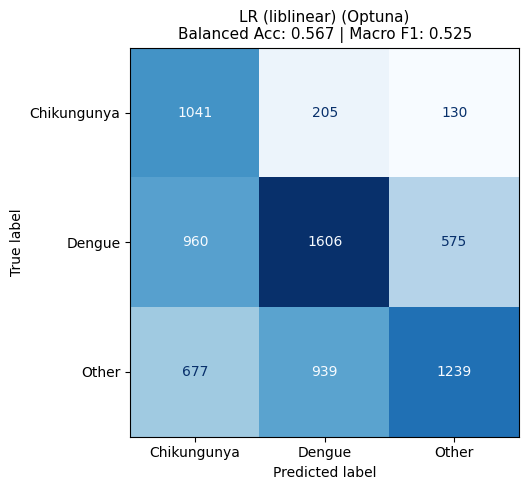

In [53]:
cc_lr_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), lr_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), lr_cat_cols)
])

cclr_pipeline2 = Pipeline([
    ('preprocessor', cc_lr_preprocessor),
    ('classifier', OneVsRestClassifier(
        LogisticRegression(
            random_state=RANDOM_STATE,
            solver="liblinear",
            l1_ratio=0,
            dual=True,
            fit_intercept=True
        )
    ))
])

cclr_param2 = {
    "classifier__estimator__max_iter": IntDistribution(3900, 5000, step=100),
    "classifier__estimator__C": FloatDistribution(1e-3, 5, log=True),
    # "classifier__solver": CategoricalDistribution(["lbfgs", "liblinear", "saga"]),
    # "classifier__estimator__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__estimator__class_weight": CategoricalDistribution([None, "balanced"]),
    "classifier__estimator__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__estimator__intercept_scaling": FloatDistribution(0.1, 10.0, log=True),
}

cclr_search2 = OptunaSearchCV(
    estimator=cclr_pipeline2,
    param_distributions=cclr_param2,
    cv=cv,
    scoring="f1_macro",
    n_trials=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

cclr_search2.fit(Xcc_train_lr, ycc_train_lr)

print("LR best score:", cclr_search2.best_score_)
print("LR best params:", cclr_search2.best_params_)

cclr_best2 = cclr_search2.best_estimator_

ccres_lr2 = evaluate_model(
    "LR (liblinear) (Optuna)",
    cclr_best2,
    Xcc_train_lr, ycc_train_lr,
    Xcc_test_lr, ycc_test_lr,
    le.classes_
)
results_cc.append(ccres_lr2)

LR best score: 0.5710979961995586
LR best params: {'classifier__estimator__C': 0.6924150974751488, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__tol': 0.0024605046266131365, 'classifier__estimator__intercept_scaling': 0.17173755394370507}

LR best score: 0.5704500267320947
LR best params: {'classifier__estimator__max_iter': 2600, 'classifier__estimator__C': 1.956032000452558, 'classifier__estimator__class_weight': 'balanced', 'classifier__estimator__tol': 0.001987457725563391, 'classifier__estimator__intercept_scaling': 8.688730436778028}



### RidgeClassifier

#### Recife

[I 2026-06-08 18:27:15,676] A new study created in memory with name: no-name-0cbfc959-bf41-4a6e-9c30-59a47c792c92


RC Train: (29576, 60)  |  RC Test: (7395, 60)


[I 2026-06-08 18:27:20,621] Trial 5 finished with value: 0.5328782249510984 and parameters: {'classifier__alpha': 17.60458957142617, 'classifier__fit_intercept': False, 'classifier__tol': 0.0006949065535355941}. Best is trial 5 with value: 0.5328782249510984.
[I 2026-06-08 18:27:20,704] Trial 4 finished with value: 0.5326490219604272 and parameters: {'classifier__alpha': 15.77634247452088, 'classifier__fit_intercept': False, 'classifier__tol': 0.005421567398034148}. Best is trial 5 with value: 0.5328782249510984.
[I 2026-06-08 18:27:20,774] Trial 13 finished with value: 0.532784519972658 and parameters: {'classifier__alpha': 13.005175405391064, 'classifier__fit_intercept': False, 'classifier__tol': 0.007556240873778791}. Best is trial 5 with value: 0.5328782249510984.
[I 2026-06-08 18:27:20,801] Trial 2 finished with value: 0.5328476753638822 and parameters: {'classifier__alpha': 17.525415234073414, 'classifier__fit_intercept': False, 'classifier__tol': 0.0012965229366155072}. Best is 

Ridge best score: 0.5340039827315626
Ridge best params: {'classifier__alpha': 15.634225402075092, 'classifier__fit_intercept': True, 'classifier__tol': 0.00036129522802015395}

  Ridge Classifier (Optuna)
  Balanced Accuracy : 0.5243
  Macro F1          : 0.5318

              precision    recall  f1-score   support

 Chikungunya       0.52      0.38      0.44      1370
      Dengue       0.54      0.70      0.61      3147
       Other       0.61      0.49      0.54      2878

    accuracy                           0.56      7395
   macro avg       0.56      0.52      0.53      7395
weighted avg       0.56      0.56      0.55      7395



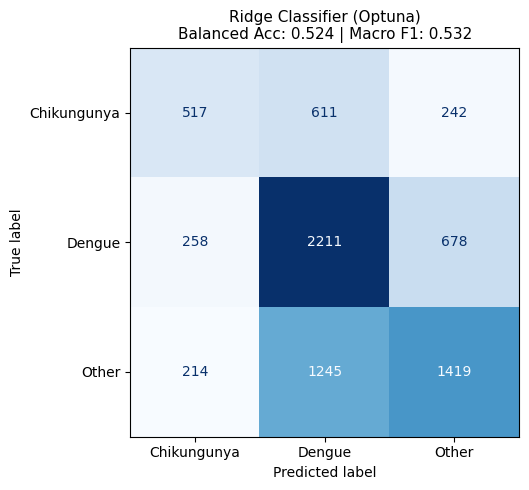

In [22]:
recife_rc = recife.dropna()
X_rc = recife_rc.drop(columns=['target', 'target_with_severity'], errors='ignore')
y_rc = le.transform(recife_rc['target'])   # reuse fitted LabelEncoder

# Stratified split on the clean subset
X_train_rc, X_test_rc, y_train_rc, y_test_rc = train_test_split(
    X_rc, y_rc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_rc
)
print(f'RC Train: {X_train_rc.shape}  |  RC Test: {X_test_rc.shape}')

rc_cat_cols = X_rc.select_dtypes(include=['object', 'string']).columns.tolist()
rc_num_cols = X_rc.select_dtypes(include=['number']).columns.tolist()

rc_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), rc_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), rc_cat_cols)
])

rc_pipeline = Pipeline([
    ('preprocessor', rc_preprocessor),
    ('classifier', RidgeClassifier(
        max_iter=4000,
        random_state=RANDOM_STATE,
        solver="cholesky",
        class_weight=None,
    ))
])

rc_param = {
    "classifier__alpha": FloatDistribution(10, 18.0, log=True),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
}

rc_search = OptunaSearchCV(
    estimator=rc_pipeline,
    param_distributions=rc_param,
    cv=cv,
    scoring="f1_macro",
    n_trials=20,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

rc_search.fit(X_train_rc, y_train_rc)

print("Ridge best score:", rc_search.best_score_)
print("Ridge best params:", rc_search.best_params_)

rc_best = rc_search.best_estimator_

res_rc = evaluate_model(
    "Ridge Classifier (Optuna)",
    rc_best,
    X_train_rc, y_train_rc,
    X_test_rc, y_test_rc,
    le.classes_
)
results.append(res_rc)

##### Solver: cholesky
Ridge best score: 0.5324469135200496

Ridge best params: {'classifier__alpha': 11.004239652831364, 'classifier__fit_intercept': False, 'classifier__tol': 0.00025640694253432504}

=======================================================
  Ridge Classifier (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5238
  Macro F1          : 0.5299

              precision    recall  f1-score   support

 Chikungunya       0.51      0.38      0.43      1370
      Dengue       0.54      0.71      0.62      3147
       Other       0.61      0.48      0.54      2878

    accuracy                           0.56      7395
   macro avg       0.55      0.52      0.53      7395
weighted avg       0.56      0.56      0.55      7395
```

##### Solver: saga
RRidge best score: 0.5322398523266554

Ridge best params: {'classifier__alpha': 12.621782384721437, 'classifier__fit_intercept': False, 'classifier__tol': 0.0014656421322513037}

=======================================================
  Ridge Classifier (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5230
  Macro F1          : 0.5291

              precision    recall  f1-score   support

 Chikungunya       0.51      0.38      0.43      1370
      Dengue       0.54      0.71      0.62      3147
       Other       0.61      0.48      0.54      2878

    accuracy                           0.56      7395
   macro avg       0.55      0.52      0.53      7395
weighted avg       0.56      0.56      0.55      7395
```

#### Concat

[I 2026-06-08 21:58:13,464] A new study created in memory with name: no-name-54087e3e-698b-4c7c-a556-b73543a32ccf


RC Train: (10731, 60)  |  RC Test: (7372, 60)


[I 2026-06-08 21:58:20,755] Trial 8 finished with value: 0.5504670730405958 and parameters: {'classifier__max_iter': 1560, 'classifier__alpha': 7.743415783277424, 'classifier__fit_intercept': False, 'classifier__tol': 0.008231615183332644}. Best is trial 8 with value: 0.5504670730405958.
[I 2026-06-08 21:58:21,400] Trial 6 finished with value: 0.5500401050919879 and parameters: {'classifier__max_iter': 1600, 'classifier__alpha': 14.99434168548669, 'classifier__fit_intercept': True, 'classifier__tol': 0.007282419226814329}. Best is trial 8 with value: 0.5504670730405958.
[I 2026-06-08 21:58:21,612] Trial 12 finished with value: 0.5505274008374155 and parameters: {'classifier__max_iter': 1520, 'classifier__alpha': 8.9801370886247, 'classifier__fit_intercept': False, 'classifier__tol': 0.007695882718983287}. Best is trial 12 with value: 0.5505274008374155.
[I 2026-06-08 21:58:22,106] Trial 10 finished with value: 0.5499858481340383 and parameters: {'classifier__max_iter': 1480, 'classifie

RC best score: 0.5507083588486104
RC best params: {'classifier__max_iter': 1520, 'classifier__alpha': 10.613131982356231, 'classifier__fit_intercept': False, 'classifier__tol': 0.009839415402081124}

  RC (saga) (Optuna)
  Balanced Accuracy : 0.5369
  Macro F1          : 0.4624

              precision    recall  f1-score   support

 Chikungunya       0.33      0.86      0.48      1376
      Dengue       0.55      0.48      0.51      3141
       Other       0.70      0.27      0.39      2855

    accuracy                           0.47      7372
   macro avg       0.53      0.54      0.46      7372
weighted avg       0.57      0.47      0.46      7372



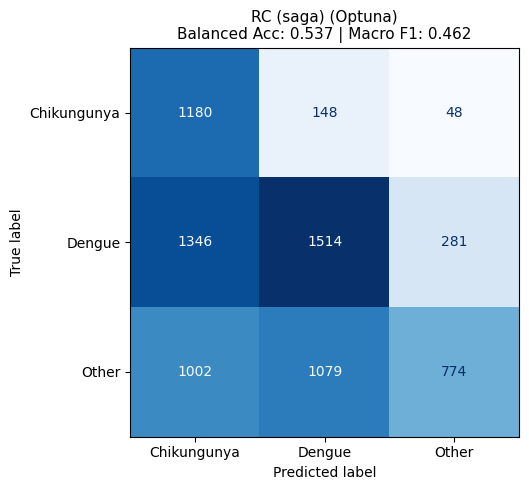

In [51]:
# --- Drop ALL rows that contain any missing value ---

Xcc_rc = pd.concat([cc_train2, cc_test2], ignore_index=True).drop(columns=["target"])

Xcc_train_rc, Xcc_test_rc, ycc_train_rc, ycc_test_rc = cc_train2.drop(columns=["target"]), cc_test2.drop(columns=["target"]), cc_train2["target"], cc_test2["target"]
print(f'RC Train: {Xcc_train_rc.shape}  |  RC Test: {Xcc_test_rc.shape}')

rc_cat_cols = Xcc_rc.select_dtypes(include=['object', 'string']).columns.tolist()
rc_num_cols = Xcc_rc.select_dtypes(include=['number']).columns.tolist()

cc_rc_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), rc_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), rc_cat_cols)
])

ccrc_pipeline = Pipeline([
    ('preprocessor', cc_rc_preprocessor),
    ('classifier', RidgeClassifier(
        random_state=RANDOM_STATE,
        solver="saga",
    ))
])

ccrc_param = {
    "classifier__max_iter": IntDistribution(1400, 1600, step=20),
    "classifier__alpha": FloatDistribution(7.367123, 18.0, log=True),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__tol": FloatDistribution(1e-3, 1e-2, log=True),
}

ccrc_search = OptunaSearchCV(
    estimator=ccrc_pipeline,
    param_distributions=ccrc_param,
    cv=cv,
    scoring="f1_macro",
    n_trials=70,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

ccrc_search.fit(Xcc_train_rc, ycc_train_rc)

print("RC best score:", ccrc_search.best_score_)
print("RC best params:", ccrc_search.best_params_)

ccrc_best = ccrc_search.best_estimator_

ccres_rc = evaluate_model(
    "RC (saga) (Optuna)",
    ccrc_best,
    Xcc_train_rc, ycc_train_rc,
    Xcc_test_rc, ycc_test_rc,
    le.classes_
)
results_cc.append(ccres_rc)

RC best score: 0.5506967075162512
RC best params: {'classifier__max_iter': 1400, 'classifier__alpha': 14.5116001508256, 'classifier__fit_intercept': False, 'classifier__tol': 0.009424201190792096}
RC best score: 0.551013960275957
RC best params: {'classifier__max_iter': 1480, 'classifier__alpha': 17.971050956389703, 'classifier__fit_intercept': False, 'classifier__tol': 0.009933336502723955}
RC best score: 0.5505040455507765
RC best params: {'classifier__max_iter': 1660, 'classifier__alpha': 1.8207716130841216, 'classifier__fit_intercept': False, 'classifier__tol': 0.008657986772702504}

RC best score: 0.5505174743883312
RC best params: {'classifier__max_iter': 5000, 'classifier__alpha': 0.3764627599718955, 'classifier__fit_intercept': True, 'classifier__tol': 0.009779029035109243}

RC best score: 0.5506397107810634
RC best params: {'classifier__max_iter': 4800, 'classifier__alpha': 6.253830912479128, 'classifier__fit_intercept': False, 'classifier__tol': 0.009802139620410984}

RC best score: 0.5505233462497199
RC best params: {'classifier__max_iter': 4280, 'classifier__alpha': 3.249421727361303, 'classifier__fit_intercept': False, 'classifier__tol': 0.009899109569490862}

### SGDClassifier

#### Recife

SGDC Train: (29576, 60)  |  SGDC Test: (7395, 60)

[I 2026-06-08 18:28:55,248] A new study created in memory with name: no-name-5fd555ee-742a-4422-bbe2-fa0bf948167e


[I 2026-06-08 18:28:58,090] Trial 7 finished with value: 0.3570523032210521 and parameters: {'classifier__loss': 'huber', 'classifier__penalty': 'l2', 'classifier__alpha': 0.037638691352835256, 'classifier__fit_intercept': False, 'classifier__tol': 0.00015894864593488884, 'classifier__epsilon': 0.0033944238580280186, 'classifier__learning_rate': 'invscaling', 'classifier__power_t': 0.2566585545975425, 'classifier__eta0': 0.011020597300569658, 'classifier__class_weight': None}. Best is trial 7 with value: 0.3570523032210521.
[I 2026-06-08 18:28:58,293] Trial 2 finished with value: 0.16306937213490258 and parameters: {'classifier__loss': 'hinge', 'classifier__penalty': 'l2', 'classifier__alpha': 11.51991915346787, 'classifier__fit_intercept': False, 'classifier__tol': 0.0002473392365939223, 'classifier__epsilon': 0.09198539955136487, 'classifier__learning_rate': 'constant', 'classifier__power_t': 0.02840823135409848, 'classifier__eta0': 0.6481496653642072, 'classifier__class_weight': Non

SGD best score: 0.5453618337193267
SGD best params: {'classifier__loss': 'squared_hinge', 'classifier__penalty': 'l1', 'classifier__alpha': 7.11172708479508e-05, 'classifier__fit_intercept': True, 'classifier__tol': 0.0001438203993850583, 'classifier__epsilon': 0.006156454336996739, 'classifier__learning_rate': 'adaptive', 'classifier__power_t': 0.40142582994125486, 'classifier__eta0': 0.2032670729413129, 'classifier__class_weight': 'balanced'}

  SGD Classifier (Optuna)
  Balanced Accuracy : 0.5687
  Macro F1          : 0.5462

              precision    recall  f1-score   support

 Chikungunya       0.43      0.65      0.52      1370
      Dengue       0.58      0.56      0.57      3147
       Other       0.62      0.49      0.55      2878

    accuracy                           0.55      7395
   macro avg       0.54      0.57      0.55      7395
weighted avg       0.57      0.55      0.55      7395



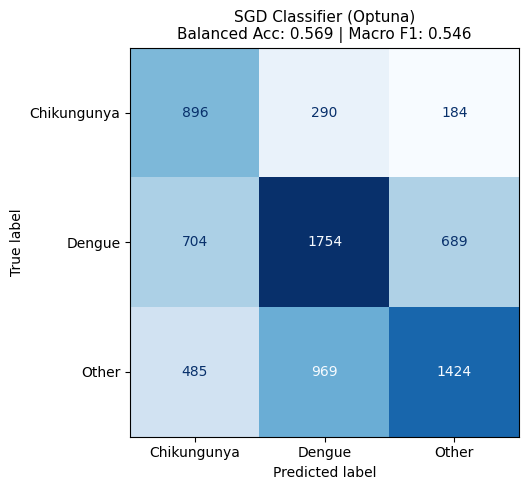

In [24]:
recife_sgdc = recife.dropna()
X_sgdc = recife_sgdc.drop(columns=['target', 'target_with_severity'], errors='ignore')
y_sgdc = le.transform(recife_sgdc['target'])   # reuse fitted LabelEncoder

# Stratified split on the clean subset
X_train_sgdc, X_test_sgdc, y_train_sgdc, y_test_sgdc = train_test_split(
    X_sgdc, y_sgdc, test_size=0.2, random_state=RANDOM_STATE, stratify=y_sgdc
)
print(f'SGDC Train: {X_train_sgdc.shape}  |  SGDC Test: {X_test_sgdc.shape}')

sgdc_cat_cols = X_sgdc.select_dtypes(include=['object', 'string']).columns.tolist()
sgdc_num_cols = X_sgdc.select_dtypes(include=['number']).columns.tolist()

sgdc_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), sgdc_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), sgdc_cat_cols)
])

sgdc_pipeline = Pipeline([
    ('preprocessor', sgdc_preprocessor),
    ('classifier', SGDClassifier(
        max_iter=3000,
        random_state=RANDOM_STATE,
    ))
])

sgdc_param = {
    "classifier__loss": CategoricalDistribution(['hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive']),
    "classifier__penalty": CategoricalDistribution(['l2', 'l1', 'elasticnet']),
    "classifier__alpha": FloatDistribution(1e-5, 20, log=True),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__epsilon": FloatDistribution(1e-3, 1, log=True),
    "classifier__learning_rate": CategoricalDistribution(['constant', 'optimal', 'invscaling', 'adaptive']),
    "classifier__power_t": FloatDistribution(1e-2, 1.5, log=True),
    "classifier__eta0": FloatDistribution(1e-3, 2, log=True),
    "classifier__class_weight": CategoricalDistribution(['balanced', None]),
}

sgdc_search = OptunaSearchCV(
    estimator=sgdc_pipeline,
    param_distributions=sgdc_param,
    cv=cv,
    scoring="f1_macro",
    n_trials=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

sgdc_search.fit(X_train_sgdc, y_train_sgdc)

print("SGD best score:", sgdc_search.best_score_)
print("SGD best params:", sgdc_search.best_params_)

sgdc_best = sgdc_search.best_estimator_

res_sgdc = evaluate_model(
    "SGD Classifier (Optuna)",
    sgdc_best,
    X_train_sgdc, y_train_sgdc,
    X_test_sgdc, y_test_sgdc,
    le.classes_
)
results.append(res_sgdc)

SGD best score: 0.5354872872987052

SGD best params: {'classifier__loss': 'squared_hinge', 'classifier__penalty': 'l2', 'classifier__alpha': 0.0009645767585516975, 'classifier__fit_intercept': True, 'classifier__tol': 0.0003202481317848167, 'classifier__epsilon': 0.005772075282658919, 'classifier__learning_rate': 'adaptive', 'classifier__power_t': 0.018171585254386568, 'classifier__eta0': 0.015908567782468682, 'classifier__class_weight': None}

=======================================================
  SGD Classifier (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5268
  Macro F1          : 0.5333

              precision    recall  f1-score   support

 Chikungunya       0.51      0.39      0.45      1370
      Dengue       0.55      0.70      0.61      3147
       Other       0.61      0.49      0.54      2878

    accuracy                           0.56      7395
   macro avg       0.56      0.53      0.53      7395
weighted avg       0.56      0.56      0.55      7395
```

#### Concat

SGD Classifier Train: (10731, 60)  |  SGD Classifier Test: (7372, 60)

[I 2026-06-08 18:32:19,567] A new study created in memory with name: no-name-a5975f38-e418-4aab-80ee-c914a77eb722


[I 2026-06-08 18:32:21,142] Trial 6 finished with value: 0.48200066693299554 and parameters: {'classifier__loss': 'huber', 'classifier__penalty': 'l2', 'classifier__alpha': 0.0799014553821835, 'classifier__fit_intercept': True, 'classifier__tol': 0.0022310350874142765, 'classifier__epsilon': 0.2341017727615356, 'classifier__learning_rate': 'constant', 'classifier__power_t': 0.1694228595655142, 'classifier__eta0': 0.010592591625455906, 'classifier__class_weight': None}. Best is trial 6 with value: 0.48200066693299554.
[I 2026-06-08 18:32:21,156] Trial 5 finished with value: 0.37877418982532174 and parameters: {'classifier__loss': 'huber', 'classifier__penalty': 'l2', 'classifier__alpha': 0.0008787344315670161, 'classifier__fit_intercept': False, 'classifier__tol': 0.000193196897842836, 'classifier__epsilon': 0.0012700999848239297, 'classifier__learning_rate': 'constant', 'classifier__power_t': 1.3093147036565331, 'classifier__eta0': 0.0068923237035814254, 'classifier__class_weight': Non

SGD Classifier best score: 0.5499442294928698
SGD Classifier best params: {'classifier__loss': 'huber', 'classifier__penalty': 'l1', 'classifier__alpha': 0.003673835523220131, 'classifier__fit_intercept': True, 'classifier__tol': 0.004975723253612435, 'classifier__epsilon': 0.5138946006181873, 'classifier__learning_rate': 'adaptive', 'classifier__power_t': 0.17200366326248426, 'classifier__eta0': 0.1263403965067379, 'classifier__class_weight': 'balanced'}

  SGD Classifier (Optuna)
  Balanced Accuracy : 0.5353
  Macro F1          : 0.4679

              precision    recall  f1-score   support

 Chikungunya       0.34      0.83      0.49      1376
      Dengue       0.54      0.48      0.51      3141
       Other       0.68      0.29      0.41      2855

    accuracy                           0.47      7372
   macro avg       0.52      0.54      0.47      7372
weighted avg       0.56      0.47      0.47      7372



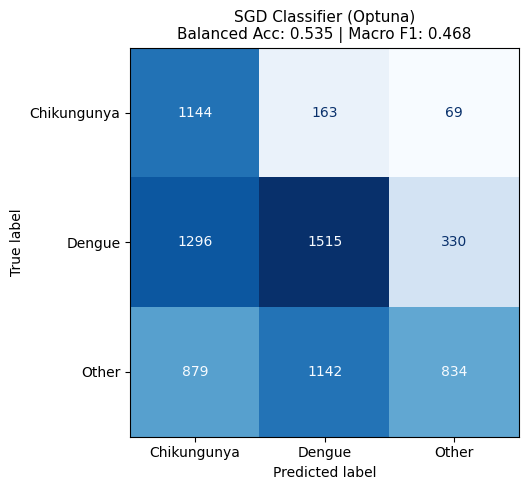

In [25]:
# --- Drop ALL rows that contain any missing value ---

# Stratified split on the clean subset
Xcc_sgdc = pd.concat([cc_train2, cc_test2], ignore_index=True).drop(columns=["target"])

Xcc_train_sgdc, Xcc_test_sgdc, ycc_train_sgdc, ycc_test_sgdc = cc_train2.drop(columns=["target"]), cc_test2.drop(columns=["target"]), cc_train2["target"], cc_test2["target"]
print(f'SGD Classifier Train: {Xcc_train_sgdc.shape}  |  SGD Classifier Test: {Xcc_test_sgdc.shape}')

sgdc_cat_cols = Xcc_sgdc.select_dtypes(include=['object', 'string']).columns.tolist()
sgdc_num_cols = Xcc_sgdc.select_dtypes(include=['number']).columns.tolist()

cc_sgdc_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), sgdc_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), sgdc_cat_cols)
])

ccsgdc_pipeline = Pipeline([
    ('preprocessor', cc_sgdc_preprocessor),
    ('classifier', SGDClassifier(
        max_iter=4000,
        random_state=RANDOM_STATE,
    ))
])

ccsgdc_param = {
    "classifier__loss": CategoricalDistribution(['hinge', 'log_loss', 'modified_huber', 'squared_hinge', 'perceptron', 'squared_error', 'huber', 'epsilon_insensitive', 'squared_epsilon_insensitive']),
    "classifier__penalty": CategoricalDistribution(['l2', 'l1', 'elasticnet']),
    "classifier__alpha": FloatDistribution(1e-5, 20, log=True),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__epsilon": FloatDistribution(1e-3, 1, log=True),
    "classifier__learning_rate": CategoricalDistribution(['constant', 'optimal', 'invscaling', 'adaptive']),
    "classifier__power_t": FloatDistribution(1e-2, 1.5, log=True),
    "classifier__eta0": FloatDistribution(1e-3, 2, log=True),
    "classifier__class_weight": CategoricalDistribution(['balanced', None]),
}

ccsgdc_search = OptunaSearchCV(
    estimator=ccsgdc_pipeline,
    param_distributions=ccsgdc_param,
    cv=cv,
    scoring="f1_macro",
    n_trials=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

ccsgdc_search.fit(Xcc_train_sgdc, ycc_train_sgdc)

print("SGD Classifier best score:", ccsgdc_search.best_score_)
print("SGD Classifier best params:", ccsgdc_search.best_params_)

ccsgdc_best = ccsgdc_search.best_estimator_

ccres_sgdc = evaluate_model(
    "SGD Classifier (Optuna)",
    ccsgdc_best,
    Xcc_train_sgdc, ycc_train_sgdc,
    Xcc_test_sgdc, ycc_test_sgdc,
    le.classes_
)
results_cc.append(ccres_sgdc)

SGD Classifier best score: 0.5699018707998098
SGD Classifier best params: {'classifier__loss': 'log_loss', 'classifier__penalty': 'l2', 'classifier__alpha': 1.7602882315959455e-05, 'classifier__fit_intercept': False, 'classifier__tol': 0.0019681365802091716, 'classifier__epsilon': 0.0015046551015638688, 'classifier__learning_rate': 'adaptive', 'classifier__power_t': 0.3822288427552992, 'classifier__eta0': 0.009761115309346292, 'classifier__class_weight': None}

=======================================================
  SGD Classifier (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5760
  Macro F1          : 0.4891

              precision    recall  f1-score   support

 Chikungunya       0.29      0.79      0.42      1419
      Dengue       0.48      0.36      0.41      4709
       Other       0.70      0.58      0.63      7349

    accuracy                           0.52     13477
   macro avg       0.49      0.58      0.49     13477
weighted avg       0.58      0.52      0.53     13477
```

### PassiveAggressiveClassifier

PassiveAggressive Train: (29576, 60) | PassiveAgressive Test: (7395, 60)

[I 2026-06-08 18:35:22,715] A new study created in memory with name: no-name-a7327287-23aa-40bf-b810-a23d1d0e99c4


[I 2026-06-08 18:35:25,715] Trial 6 finished with value: 0.544031669481836 and parameters: {'classifier__C': 0.002456980942433404, 'classifier__fit_intercept': True, 'classifier__tol': 0.004223433572384913, 'classifier__early_stopping': False, 'classifier__loss': 'squared_hinge', 'classifier__class_weight': 'balanced', 'classifier__average': 20}. Best is trial 6 with value: 0.544031669481836.
[I 2026-06-08 18:35:25,934] Trial 3 finished with value: 0.5461611924554616 and parameters: {'classifier__C': 0.29372376947952356, 'classifier__fit_intercept': True, 'classifier__tol': 0.003333291472308608, 'classifier__early_stopping': False, 'classifier__loss': 'hinge', 'classifier__class_weight': 'balanced', 'classifier__average': 4}. Best is trial 3 with value: 0.5461611924554616.
[I 2026-06-08 18:35:26,181] Trial 0 finished with value: 0.5461287601654685 and parameters: {'classifier__C': 0.01674211521410979, 'classifier__fit_intercept': True, 'classifier__tol': 0.0032587856240989172, 'classif

PassiveAggressive best score: 0.5461611924554616
PassiveAggressive best params: {'classifier__C': 0.29372376947952356, 'classifier__fit_intercept': True, 'classifier__tol': 0.003333291472308608, 'classifier__early_stopping': False, 'classifier__loss': 'hinge', 'classifier__class_weight': 'balanced', 'classifier__average': 4}

  PassiveAggressive Classifier (Optuna)
  Balanced Accuracy : 0.5663
  Macro F1          : 0.5529

              precision    recall  f1-score   support

 Chikungunya       0.45      0.60      0.52      1370
      Dengue       0.58      0.59      0.59      3147
       Other       0.61      0.50      0.55      2878

    accuracy                           0.56      7395
   macro avg       0.55      0.57      0.55      7395
weighted avg       0.57      0.56      0.56      7395



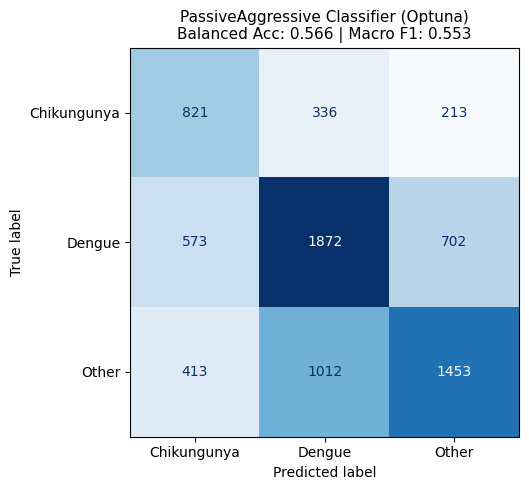

In [26]:
recife_pac = recife.dropna()
X_pac = recife_pac.drop(columns=['target', 'target_with_severity'], errors='ignore')
y_pac = le.transform(recife_pac['target'])

X_train_pac, X_test_pac, y_train_pac, y_test_pac = train_test_split(
    X_pac, y_pac, test_size=0.2, random_state=RANDOM_STATE, stratify=y_pac
)
print(f"PassiveAggressive Train: {X_train_pac.shape} | PassiveAgressive Test: {X_test_pac.shape}")

pac_cat_cols = X_pac.select_dtypes(include=['object', 'string']).columns.tolist()
pac_num_cols = X_pac.select_dtypes(include=['number']).columns.tolist()

pac_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), pac_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), pac_cat_cols)
])

pac_pipeline = Pipeline([
    ('preproccesor', pac_preprocessor),
    ('classifier', PassiveAggressiveClassifier(
        max_iter=3000,
        random_state=RANDOM_STATE,
    ))
])

pac_params = {
    "classifier__C": FloatDistribution(1e-3, 20, log=True),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__early_stopping": CategoricalDistribution([False, True]),
    "classifier__loss": CategoricalDistribution(["hinge", "squared_hinge"]),
    "classifier__class_weight": CategoricalDistribution(["balanced", None]),
    "classifier__average": IntDistribution(0, 40, step=4),
}

pac_search = OptunaSearchCV(
    estimator=pac_pipeline,
    param_distributions=pac_params,
    cv=cv,
    scoring="f1_macro",
    n_trials=10,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

pac_search.fit(X_train_pac, y_train_pac)

print("PassiveAggressive best score:", pac_search.best_score_)
print("PassiveAggressive best params:", pac_search.best_params_)

pac_best = pac_search.best_estimator_
res_pac = evaluate_model(
    "PassiveAggressive Classifier (Optuna)",
    pac_best,
    X_train_pac, y_train_pac,
    X_test_pac, y_test_pac,
    le.classes_
)
results.append(res_pac)

PassiveAggressive best score: 0.5446899431290685

PassiveAggressive best params: {'classifier__C': 0.7253488971655868, 'classifier__fit_intercept': False, 'classifier__tol': 0.000772786527767408, 'classifier__early_stopping': False, 'classifier__loss': 'squared_hinge', 'classifier__class_weight': 'balanced', 'classifier__average': 4}

=======================================================
  PassiveAggressive Classifier (Optuna)
=======================================================
```text
  Balanced Accuracy : 0.5658
  Macro F1          : 0.5519

              precision    recall  f1-score   support

 Chikungunya       0.45      0.60      0.51      1370
      Dengue       0.58      0.60      0.59      3147
       Other       0.62      0.50      0.55      2878

    accuracy                           0.56      7395
   macro avg       0.55      0.57      0.55      7395
weighted avg       0.57      0.56      0.56      7395
```

### Perceptron

Perceptron Train: (29576, 60) | Perceptron Test: (7395, 60)

[I 2026-06-08 18:35:29,141] A new study created in memory with name: no-name-6398104f-1378-43c8-9241-fd381fff51e2


[I 2026-06-08 18:35:33,511] Trial 4 finished with value: 0.42676101977959835 and parameters: {'classifier__penalty': 'l2', 'classifier__alpha': 1.607363910776696e-05, 'classifier__fit_intercept': False, 'classifier__tol': 0.0035809259592435977, 'classifier__eta0': 0.05764563285600657, 'classifier__class_weight': None}. Best is trial 4 with value: 0.42676101977959835.
[I 2026-06-08 18:35:33,519] Trial 1 finished with value: 0.4165681145524921 and parameters: {'classifier__penalty': None, 'classifier__alpha': 3.105876749384272e-05, 'classifier__fit_intercept': True, 'classifier__tol': 0.0029916382684521286, 'classifier__eta0': 0.041107019619930095, 'classifier__class_weight': None}. Best is trial 4 with value: 0.42676101977959835.
[I 2026-06-08 18:35:33,810] Trial 10 finished with value: 0.45110472119113554 and parameters: {'classifier__penalty': None, 'classifier__alpha': 0.005104778722416225, 'classifier__fit_intercept': False, 'classifier__tol': 0.005664297743785817, 'classifier__eta0

Perceptron best score: 0.46131206284361354
Perceptron best params: {'classifier__penalty': 'elasticnet', 'classifier__alpha': 0.009396738047963244, 'classifier__fit_intercept': False, 'classifier__tol': 0.0010221922701529815, 'classifier__eta0': 0.2508787727962379, 'classifier__class_weight': 'balanced'}

  Perceptron (Optuna)
  Balanced Accuracy : 0.4669
  Macro F1          : 0.4639

              precision    recall  f1-score   support

 Chikungunya       0.37      0.30      0.33      1370
      Dengue       0.51      0.72      0.60      3147
       Other       0.59      0.38      0.46      2878

    accuracy                           0.51      7395
   macro avg       0.49      0.47      0.46      7395
weighted avg       0.52      0.51      0.50      7395



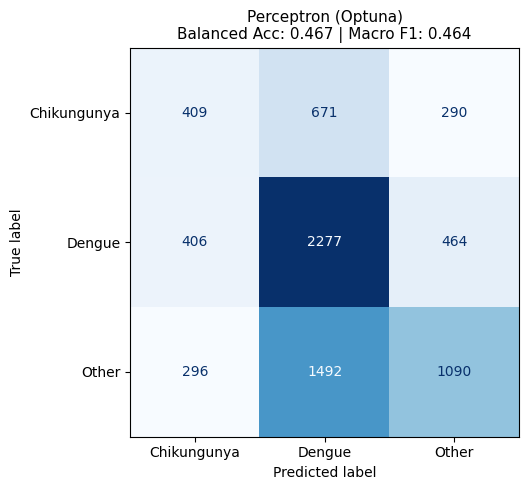

In [27]:
recife_pct = recife.dropna()
X_pct = recife_pct.drop(columns=['target', 'target_with_severity'], errors='ignore')
y_pct = le.transform(recife_pct['target'])

X_train_pct, X_test_pct, y_train_pct, y_test_pct = train_test_split(
    X_pct, y_pct, test_size=0.2, random_state=RANDOM_STATE, stratify=y_pct
)
print(f"Perceptron Train: {X_train_pct.shape} | Perceptron Test: {X_test_pct.shape}")

pct_cat_cols = X_pct.select_dtypes(include=['object', 'string']).columns.tolist()
pct_num_cols = X_pct.select_dtypes(include=['number']).columns.tolist()

pct_preprocessor = ColumnTransformer([
    ('num', StandardScaler(), pct_num_cols),
    ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), pct_cat_cols)
])

pct_pipeline = Pipeline([
    ('preproccesor', pct_preprocessor),
    ('classifier', Perceptron(
        max_iter=3000,
        random_state=RANDOM_STATE,
    ))
])

pct_params = {
    "classifier__penalty": CategoricalDistribution(['l2', 'l1', 'elasticnet', None]),
    "classifier__alpha": FloatDistribution(1e-5, 1e-2, log=True),
    "classifier__fit_intercept": CategoricalDistribution([True, False]),
    "classifier__tol": FloatDistribution(1e-4, 1e-2, log=True),
    "classifier__eta0": FloatDistribution(1e-2, 1.5, log=True),
    "classifier__class_weight": CategoricalDistribution(["balanced", None]),
}

pct_search = OptunaSearchCV(
    estimator=pct_pipeline,
    param_distributions=pct_params,
    cv=cv,
    scoring="f1_macro",
    n_trials=50,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True,
)

pct_search.fit(X_train_pct, y_train_pct)

print("Perceptron best score:", pct_search.best_score_)
print("Perceptron best params:", pct_search.best_params_)

pct_best = pct_search.best_estimator_
res_pct = evaluate_model(
    "Perceptron (Optuna)",
    pct_best,
    X_train_pct, y_train_pct,
    X_test_pct, y_test_pct,
    le.classes_
)
results.append(res_pct)

## 7. Model 4 — HistGradientBoosting
Natively supports missing values. Class weights applied via `class_weight`.

[I 2026-06-08 18:35:50,596] A new study created in memory with name: no-name-62517f1b-107f-4106-a66b-d6761a0439c5
[I 2026-06-08 18:37:49,148] Trial 15 finished with value: 0.6027776236200059 and parameters: {'classifier__learning_rate': 0.08728561882753508, 'classifier__max_iter': 700, 'classifier__max_depth': 14, 'classifier__max_leaf_nodes': 44, 'classifier__min_samples_leaf': 16, 'classifier__l2_regularization': 0.008184482861946238, 'classifier__max_bins': 211}. Best is trial 15 with value: 0.6027776236200059.
[I 2026-06-08 18:37:51,270] Trial 2 finished with value: 0.6019626833265239 and parameters: {'classifier__learning_rate': 0.08097008772179495, 'classifier__max_iter': 800, 'classifier__max_depth': 18, 'classifier__max_leaf_nodes': 41, 'classifier__min_samples_leaf': 19, 'classifier__l2_regularization': 1.2125527434591636e-05, 'classifier__max_bins': 222}. Best is trial 15 with value: 0.6027776236200059.
[I 2026-06-08 18:37:52,956] Trial 11 finished with value: 0.6023844876414

HGB best score: 0.60454062315148
HGB best params: {'classifier__learning_rate': 0.027778346150214392, 'classifier__max_iter': 440, 'classifier__max_depth': 11, 'classifier__max_leaf_nodes': 39, 'classifier__min_samples_leaf': 28, 'classifier__l2_regularization': 1.118521552448198e-05, 'classifier__max_bins': 183}

  HistGradientBoosting (Optuna)
  Balanced Accuracy : 0.5955
  Macro F1          : 0.5984

              precision    recall  f1-score   support

 Chikungunya       0.55      0.51      0.53      1369
      Dengue       0.62      0.71      0.66      3148
       Other       0.65      0.57      0.61      2883

    accuracy                           0.62      7400
   macro avg       0.61      0.60      0.60      7400
weighted avg       0.62      0.62      0.61      7400



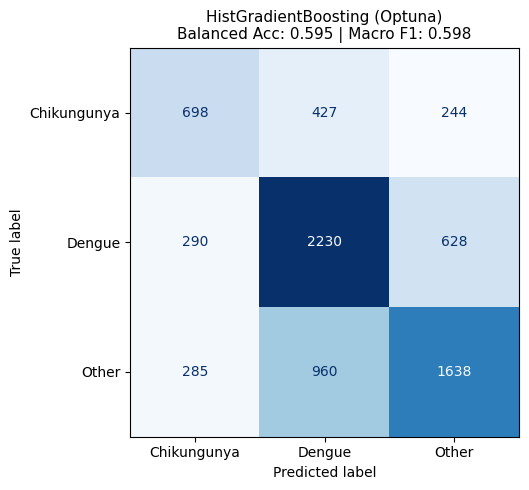

In [28]:
# HistGradientBoosting handles NaN natively for numerics,
# but categoricals still need encoding
from sklearn.preprocessing import OrdinalEncoder as OE
X_train_hgb, X_test_hgb = X_train.copy(), X_test.copy()

hgb_cat_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OE(handle_unknown='use_encoded_value', unknown_value=-1))
])

hgb_preprocessor = ColumnTransformer([
    ('num', 'passthrough', num_cols),  # no scaling needed for HGB
    ('cat', hgb_cat_transformer, cat_cols)
])

# Compute class weights manually
from sklearn.utils.class_weight import compute_class_weight
cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
hgb_w = np.array([cw[c] for c in y_train])

hgb_model = Pipeline([
    ('preprocessor', hgb_preprocessor),
    ('classifier', HistGradientBoostingClassifier(
        random_state=RANDOM_STATE,
        early_stopping=True,
        class_weight=None,
    ))
])

hgb_param_distributions = {
    'classifier__learning_rate': FloatDistribution(1e-2, 0.1, log=True),
    'classifier__max_iter': IntDistribution(400, 800, step=20),
    'classifier__max_depth': IntDistribution(10, 18),
    'classifier__max_leaf_nodes': IntDistribution(30, 63),
    'classifier__min_samples_leaf': IntDistribution(16, 40, step=3),
    'classifier__l2_regularization': FloatDistribution(1e-6, 10.0, log=True),
    'classifier__max_bins': IntDistribution(180, 255),
}
{'classifier__learning_rate': 0.041781191122534866, 'classifier__max_iter': 650, 'classifier__max_depth': 15, 'classifier__max_leaf_nodes': 48,
 'classifier__min_samples_leaf': 25, 'classifier__l2_regularization': 0.04868692584193857, 'classifier__max_bins': 251}
hgb_search = OptunaSearchCV(
    estimator=hgb_model,
    param_distributions=hgb_param_distributions,
    cv=cv,
    scoring=f1_macro,
    n_trials=25,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=1,
    refit=True
)

hgb_search.fit(X_train_hgb, y_train)

print("HGB best score:", hgb_search.best_score_)
print("HGB best params:", hgb_search.best_params_)

hgb_best = hgb_search.best_estimator_

res = evaluate_model(
    'HistGradientBoosting (Optuna)',
    hgb_best,
    X_train_hgb, y_train,
    X_test_hgb, y_test,
    le.classes_
)
results.append(res)

HGB best score: 0.6060150671336084

HGB best params: {'classifier__learning_rate': 0.08025861717554916, 'classifier__max_iter': 600, 'classifier__max_depth': 17, 'classifier__max_leaf_nodes': 50, 'classifier__min_samples_leaf': 34, 'classifier__l2_regularization': 0.003482251406470383, 'classifier__max_bins': 224}

=======================================================
  HistGradientBoosting (Optuna)
=======================================================
```
  Balanced Accuracy : 0.5957
  Macro F1          : 0.5976

              precision    recall  f1-score   support

 Chikungunya       0.54      0.52      0.53      1369
      Dengue       0.62      0.70      0.66      3148
       Other       0.65      0.57      0.61      2883

    accuracy                           0.62      7400
   macro avg       0.60      0.60      0.60      7400
weighted avg       0.62      0.62      0.61      7400

```

#### Concat

[I 2026-06-08 21:13:51,070] A new study created in memory with name: hgb_concat_macro_f1


Xcc_train_hgb: (17028, 60)
ycc_train_arr: (17028,)
Xcc_test_hgb: (15066, 60)
ycc_test_arr: (15066,)
HGB categorical feature indices: [55, 56, 57, 58, 59]


  0%|          | 0/25 [00:00<?, ?it/s]

[I 2026-06-08 21:13:58,151] Trial 0 finished with value: 0.6633149475747313 and parameters: {'learning_rate': 0.023688639503640783, 'max_iter': 780, 'max_depth': 14, 'max_leaf_nodes': 46, 'min_samples_leaf': 23, 'l2_regularization': 1.2358382772306929e-05, 'max_bins': 135, 'validation_fraction': 0.22992642186624027, 'n_iter_no_change': 22}. Best is trial 0 with value: 0.6633149475747313.
[I 2026-06-08 21:14:02,341] Trial 1 finished with value: 0.6664114946585168 and parameters: {'learning_rate': 0.051059032093947576, 'max_iter': 400, 'max_depth': 16, 'max_leaf_nodes': 56, 'min_samples_leaf': 25, 'l2_regularization': 1.8740223688836324e-05, 'max_bins': 151, 'validation_fraction': 0.14563633644393065, 'n_iter_no_change': 21}. Best is trial 1 with value: 0.6664114946585168.
[I 2026-06-08 21:14:07,890] Trial 2 finished with value: 0.6632860960834114 and parameters: {'learning_rate': 0.027036160666620016, 'max_iter': 520, 'max_depth': 12, 'max_leaf_nodes': 26, 'min_samples_leaf': 29, 'l2_re

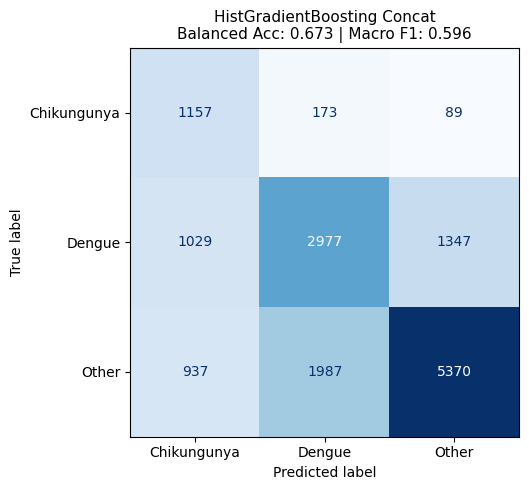

In [42]:
Xcc_train_hgb = Xcc_train.copy()
Xcc_test_hgb = Xcc_test.copy()

ycc_train_arr = np.asarray(ycc_train)
ycc_test_arr = np.asarray(ycc_test)

# Replace inf values
Xcc_train_hgb = Xcc_train_hgb.replace([np.inf, -np.inf], np.nan)
Xcc_test_hgb = Xcc_test_hgb.replace([np.inf, -np.inf], np.nan)

# Recompute columns from the concat dataset
cc_num_cols = Xcc_train_hgb.select_dtypes(include=["number", "bool"]).columns.tolist()
cc_cat_cols = [c for c in Xcc_train_hgb.columns if c not in cc_num_cols]

print("Xcc_train_hgb:", Xcc_train_hgb.shape)
print("ycc_train_arr:", ycc_train_arr.shape)
print("Xcc_test_hgb:", Xcc_test_hgb.shape)
print("ycc_test_arr:", ycc_test_arr.shape)

assert len(Xcc_train_hgb) == len(ycc_train_arr)
assert len(Xcc_test_hgb) == len(ycc_test_arr)

def make_hgb_preprocessor():
    hgb_cat_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OrdinalEncoder(
            handle_unknown="use_encoded_value",
            unknown_value=np.nan,
            encoded_missing_value=np.nan,
            dtype=np.float64
        ))
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", "passthrough", cc_num_cols),
            ("cat", hgb_cat_transformer, cc_cat_cols),
        ],
        remainder="drop",
        verbose_feature_names_out=False
    )

    return preprocessor


cat_feature_indices = list(
    range(len(cc_num_cols), len(cc_num_cols) + len(cc_cat_cols))
)

print("HGB categorical feature indices:", cat_feature_indices)

hgb_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)

def make_hgb_model(params):
    return HistGradientBoostingClassifier(
        loss="log_loss",
        learning_rate=params["learning_rate"],
        max_iter=params["max_iter"],
        max_depth=params["max_depth"],
        max_leaf_nodes=params["max_leaf_nodes"],
        min_samples_leaf=params["min_samples_leaf"],
        l2_regularization=params["l2_regularization"],
        max_bins=params["max_bins"],
        early_stopping=True,
        validation_fraction=params["validation_fraction"],
        n_iter_no_change=params["n_iter_no_change"],
        categorical_features=cat_feature_indices,
        random_state=RANDOM_STATE
    )


def hgb_objective(trial):
    params = {
        "learning_rate": trial.suggest_float("learning_rate", 1e-2, 0.1, log=True),
        "max_iter": trial.suggest_int("max_iter", 400, 800, step=20),
        "max_depth": trial.suggest_int("max_depth", 6, 16),
        "max_leaf_nodes": trial.suggest_int("max_leaf_nodes", 20, 63),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 16, 60),
        "l2_regularization": trial.suggest_float("l2_regularization", 1e-6, 10.0, log=True),
        "max_bins": trial.suggest_int("max_bins", 128, 255),
        "validation_fraction": trial.suggest_float("validation_fraction", 0.10, 0.25),
        "n_iter_no_change": trial.suggest_int("n_iter_no_change", 10, 30),
    }

    fold_scores = []

    for train_idx, valid_idx in hgb_cv.split(Xcc_train_hgb, ycc_train_arr):
        X_fold_train = Xcc_train_hgb.iloc[train_idx]
        X_fold_valid = Xcc_train_hgb.iloc[valid_idx]

        y_fold_train = ycc_train_arr[train_idx]
        y_fold_valid = ycc_train_arr[valid_idx]

        sample_weight = compute_sample_weight(
            class_weight="balanced",
            y=y_fold_train
        )

        pipe = Pipeline(steps=[
            ("preprocessor", make_hgb_preprocessor()),
            ("classifier", make_hgb_model(params))
        ])

        pipe.fit(
            X_fold_train,
            y_fold_train,
            classifier__sample_weight=sample_weight
        )

        pred = pipe.predict(X_fold_valid)

        score = f1_score(
            y_fold_valid,
            pred,
            average="macro",
            zero_division=0
        )

        fold_scores.append(score)

    return float(np.mean(fold_scores))


hgb_study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    study_name="hgb_concat_macro_f1"
)

hgb_study.optimize(
    hgb_objective,
    n_trials=25,
    show_progress_bar=True
)

print("HGB best score:", hgb_study.best_value)
print("HGB best params:", hgb_study.best_params)


hgb_best = Pipeline(steps=[
    ("preprocessor", make_hgb_preprocessor()),
    ("classifier", make_hgb_model(hgb_study.best_params))
])

final_sample_weight = compute_sample_weight(
    class_weight="balanced",
    y=ycc_train_arr
)

hgb_best.fit(
    Xcc_train_hgb,
    ycc_train_arr,
    classifier__sample_weight=final_sample_weight
)

ycc_pred = hgb_best.predict(Xcc_test_hgb)

bal_acc = balanced_accuracy_score(ycc_test_arr, ycc_pred)
macro_f1 = f1_score(ycc_test_arr, ycc_pred, average="macro", zero_division=0)

print("\n" + "=" * 55)
print("  HistGradientBoosting (Concat + Optuna create_study)")
print("=" * 55)
print(f"  Balanced Accuracy : {bal_acc:.4f}")
print(f"  Macro F1          : {macro_f1:.4f}")
print()

print(classification_report(
    ycc_test_arr,
    ycc_pred,
    target_names=le.classes_,
    zero_division=0
))

cm = confusion_matrix(ycc_test_arr, ycc_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=le.classes_
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(
    f"HistGradientBoosting Concat\n"
    f"Balanced Acc: {bal_acc:.3f} | Macro F1: {macro_f1:.3f}",
    fontsize=11
)
plt.tight_layout()
plt.show()

results.append({
    "model": "HGB concat Optuna",
    "balanced_acc": bal_acc,
    "macro_f1": macro_f1
})

Best is trial 6 with value: 0.6677935809022344.
{'learning_rate': 0.03961867790406585, 'max_iter': 780, 'max_depth': 6, 'max_leaf_nodes': 28, 'min_samples_leaf': 18, 'l2_regularization': 0.0001893704954163131, 'max_bins': 177, 'validation_fraction': 0.1407023547660844, 'n_iter_no_change': 27}.

# 8. Model NearestNeighbor family

## KNN

[I 2026-06-08 23:43:14,321] A new study created in memory with name: no-name-830906ad-0d56-4a58-a3a6-09ac69358891
[I 2026-06-08 23:43:16,985] Trial 0 finished with value: 0.6188113128291868 and parameters: {'classifier__n_neighbors': 17, 'classifier__weights': 'uniform', 'classifier__p': 1, 'classifier__algorithm': 'auto', 'classifier__leaf_size': 21, 'classifier__n_jobs': -1}. Best is trial 0 with value: 0.6188113128291868.
[I 2026-06-08 23:43:21,631] Trial 1 finished with value: 0.6263598115699603 and parameters: {'classifier__n_neighbors': 31, 'classifier__weights': 'uniform', 'classifier__p': 1, 'classifier__algorithm': 'kd_tree', 'classifier__leaf_size': 30, 'classifier__n_jobs': -1}. Best is trial 1 with value: 0.6263598115699603.
[I 2026-06-08 23:43:22,538] Trial 2 finished with value: 0.620893310442825 and parameters: {'classifier__n_neighbors': 29, 'classifier__weights': 'distance', 'classifier__p': 2, 'classifier__algorithm': 'auto', 'classifier__leaf_size': 25, 'classifier__

KNN best score: 0.626562094904153
KNN best params: {'classifier__n_neighbors': 31, 'classifier__weights': 'distance', 'classifier__p': 1, 'classifier__algorithm': 'kd_tree', 'classifier__leaf_size': 24, 'classifier__n_jobs': None}

  KNN (Optuna)
  Balanced Accuracy : 0.6360
  Macro F1          : 0.5600

              precision    recall  f1-score   support

 Chikungunya       0.33      0.77      0.46      1419
      Dengue       0.55      0.54      0.54      5353
       Other       0.76      0.61      0.68      8294

    accuracy                           0.60     15066
   macro avg       0.55      0.64      0.56     15066
weighted avg       0.65      0.60      0.61     15066



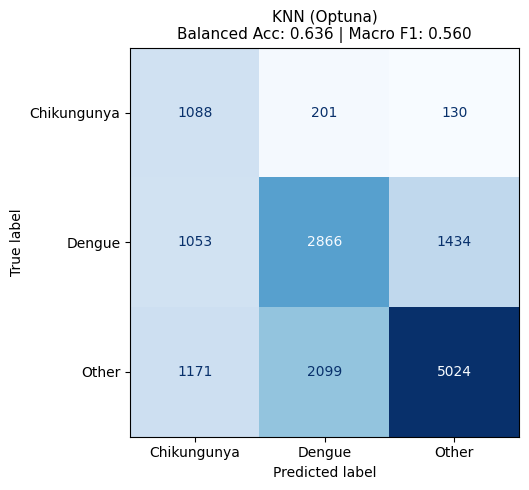

In [59]:
# numeric -> median impute + scale, categorical -> mode impute + ordinal encode.
knn_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', KNeighborsClassifier(
        metric='minkowski'
    ))
])

knn_param = {
    'classifier__n_neighbors': IntDistribution(7, 31, step=2),
    'classifier__weights': CategoricalDistribution(['uniform', 'distance']),
    'classifier__p': IntDistribution(1, 2),
    'classifier__algorithm': CategoricalDistribution(['auto', 'ball_tree', 'kd_tree', 'brute']),
    'classifier__leaf_size': IntDistribution(20, 30),
    'classifier__n_jobs': CategoricalDistribution([None, -1])  # use all cores for KNN
}

knn_search = OptunaSearchCV(
    estimator=knn_pipeline,
    param_distributions=knn_param,
    cv=StratifiedKFold(n_splits=4, shuffle=True, random_state=RANDOM_STATE),
    scoring=f1_macro,
    n_trials=20,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    refit=True
)

knn_search.fit(Xcc_train, ycc_train)

print('KNN best score:', knn_search.best_score_)
print('KNN best params:', knn_search.best_params_)

knn_best = knn_search.best_estimator_

res = evaluate_model(
    'KNN (Optuna)',
    knn_best,
    Xcc_train, ycc_train,
    Xcc_test, ycc_test,
    lecc.classes_
)
results.append(res)

## RadiusNeighborsClassifier

[I 2026-06-08 23:40:19,735] A new study created in memory with name: no-name-910e3b28-da42-4290-a8c7-f7d9deb1c485


RNC Train: (17028, 60)
RNC Test : (15066, 60)
Numeric columns: 55
Categorical columns: 5


[I 2026-06-08 23:40:24,521] Trial 0 finished with value: 0.5526535320902006 and parameters: {'classifier__radius': 7.36581473109921, 'classifier__weights': 'uniform', 'classifier__algorithm': 'ball_tree', 'classifier__leaf_size': 26, 'classifier__p': 2}. Best is trial 0 with value: 0.5526535320902006.
[I 2026-06-08 23:40:25,512] Trial 1 finished with value: 0.5808939849570015 and parameters: {'classifier__radius': 5.886947284959015, 'classifier__weights': 'uniform', 'classifier__algorithm': 'brute', 'classifier__leaf_size': 59, 'classifier__p': 2}. Best is trial 1 with value: 0.5808939849570015.
[I 2026-06-08 23:40:27,300] Trial 2 finished with value: 0.5516938470099849 and parameters: {'classifier__radius': 7.397988646623883, 'classifier__weights': 'uniform', 'classifier__algorithm': 'brute', 'classifier__leaf_size': 41, 'classifier__p': 2}. Best is trial 1 with value: 0.5808939849570015.
[I 2026-06-08 23:40:31,027] Trial 3 finished with value: 0.5279236445150365 and parameters: {'cla

RadiusNeighbors best score: 0.5924338247239808
RadiusNeighbors best params: {'classifier__radius': 5.47831123986409, 'classifier__weights': 'distance', 'classifier__algorithm': 'auto', 'classifier__leaf_size': 46, 'classifier__p': 2}

  RadiusNeighborsClassifier (Concat + Optuna)
  Balanced Accuracy : 0.6004
  Macro F1          : 0.5240

              precision    recall  f1-score   support

 Chikungunya       0.29      0.74      0.42      1419
      Dengue       0.55      0.43      0.48      5353
       Other       0.72      0.63      0.67      8294

    accuracy                           0.57     15066
   macro avg       0.52      0.60      0.52     15066
weighted avg       0.62      0.57      0.58     15066



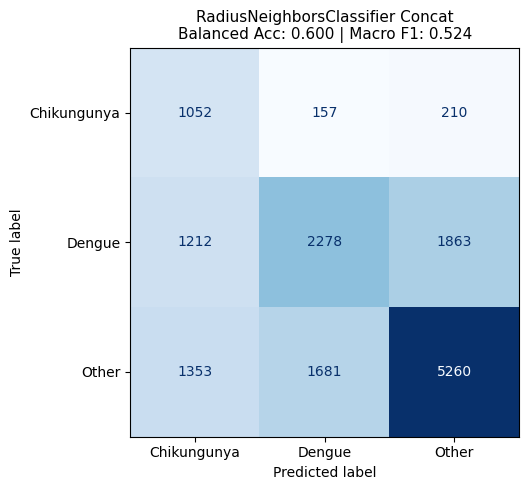

In [56]:
Xcc_train_rnc = Xcc_train.copy()
Xcc_test_rnc = Xcc_test.copy()

ycc_train_rnc = np.asarray(ycc_train)
ycc_test_rnc = np.asarray(ycc_test)

# Safety checks
assert len(Xcc_train_rnc) == len(ycc_train_rnc)
assert len(Xcc_test_rnc) == len(ycc_test_rnc)

# Replace inf
Xcc_train_rnc = Xcc_train_rnc.replace([np.inf, -np.inf], np.nan)
Xcc_test_rnc = Xcc_test_rnc.replace([np.inf, -np.inf], np.nan)

# Recompute columns from CONCAT dataset
rnc_num_cols = Xcc_train_rnc.select_dtypes(include=["number", "bool"]).columns.tolist()
rnc_cat_cols = [c for c in Xcc_train_rnc.columns if c not in rnc_num_cols]

print("RNC Train:", Xcc_train_rnc.shape)
print("RNC Test :", Xcc_test_rnc.shape)
print("Numeric columns:", len(rnc_num_cols))
print("Categorical columns:", len(rnc_cat_cols))


# oheEncoder version compatibility
try:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)


# RadiusNeighbors is distance-based:
# numeric features MUST be scaled.
# categorical features should be one-hot encoded, not ordinal-encoded.
rnc_preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), rnc_num_cols),

        ("cat", Pipeline(steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("ohe", ohe)
        ]), rnc_cat_cols),
    ],
    remainder="drop"
)


rnc_pipeline = Pipeline(steps=[
    ("preprocessor", rnc_preprocessor),
    ("classifier", RadiusNeighborsClassifier(
        outlier_label="most_frequent",
        n_jobs=-1
    ))
])


rnc_param = {
    "classifier__radius": FloatDistribution(1.0, 15.0),
    "classifier__weights": CategoricalDistribution(["uniform", "distance"]),
    "classifier__algorithm": CategoricalDistribution(["auto", "ball_tree", "kd_tree", "brute"]),
    "classifier__leaf_size": IntDistribution(20, 60),
    "classifier__p": CategoricalDistribution([1, 2]),
}


rnc_cv = StratifiedKFold(
    n_splits=3,
    shuffle=True,
    random_state=RANDOM_STATE
)


rnc_search = OptunaSearchCV(
    estimator=rnc_pipeline,
    param_distributions=rnc_param,
    cv=rnc_cv,
    scoring=f1_macro,
    n_trials=20,
    random_state=RANDOM_STATE,
    n_jobs=1,
    verbose=1,
    refit=True
)

rnc_search.fit(Xcc_train_rnc, ycc_train_rnc)

print("RadiusNeighbors best score:", rnc_search.best_score_)
print("RadiusNeighbors best params:", rnc_search.best_params_)

rnc_best = rnc_search.best_estimator_


# ============================================================
# Evaluation
# ============================================================

ycc_pred = rnc_best.predict(Xcc_test_rnc)

bal_acc = balanced_accuracy_score(ycc_test_rnc, ycc_pred)
macro_f1 = f1_score(ycc_test_rnc, ycc_pred, average="macro", zero_division=0)

print("\n" + "=" * 55)
print("  RadiusNeighborsClassifier (Concat + Optuna)")
print("=" * 55)
print(f"  Balanced Accuracy : {bal_acc:.4f}")
print(f"  Macro F1          : {macro_f1:.4f}")
print()

classes_for_report = lecc.classes_ if "lecc" in globals() else le.classes_

print(classification_report(
    ycc_test_rnc,
    ycc_pred,
    target_names=classes_for_report,
    zero_division=0
))

cm = confusion_matrix(ycc_test_rnc, ycc_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=classes_for_report
)

fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, colorbar=False, cmap="Blues")
ax.set_title(
    f"RadiusNeighborsClassifier Concat\n"
    f"Balanced Acc: {bal_acc:.3f} | Macro F1: {macro_f1:.3f}",
    fontsize=11
)
plt.tight_layout()
plt.show()


results_cc.append({
    "model": "RadiusNeighborsClassifier (Concat + Optuna)",
    "balanced_acc": bal_acc,
    "macro_f1": macro_f1
})

In [60]:
from sklearn.metrics import pairwise_distances
import numpy as np

X_debug = rnc_preprocessor.fit_transform(Xcc_train_rnc)

sample = X_debug[:1000]

dists = pairwise_distances(sample, sample, metric="minkowski", p=2)

# remove self-distance zeros
nonzero_dists = dists[dists > 0]

print("Distance min:", np.min(nonzero_dists))
print("Distance median:", np.median(nonzero_dists))
print("Distance 75%:", np.percentile(nonzero_dists, 75))
print("Distance 90%:", np.percentile(nonzero_dists, 90))
print("Distance max:", np.max(nonzero_dists))

Distance min: 0.3257946469108758
Distance median: 9.345578516199804
Distance 75%: 11.052475687605938
Distance 90%: 13.633234468236852
Distance max: 69.94507666868859


## 8. Model Comparison

                                       balanced_acc  macro_f1
model                                                        
Random Forest (Optuna)                     0.613776  0.600687
CatBoost (Optuna)                          0.617026  0.598678
HistGradientBoosting (Optuna)              0.595469  0.598372
CatBoost (Optuna)                          0.675179  0.597575
HGB concat Optuna                          0.672985  0.596105
Random Forest (Optuna)                     0.663460  0.579362
KNN (Optuna)                               0.564433  0.566668
KNN (Optuna)                               0.635959  0.560014
PassiveAggressive Classifier (Optuna)      0.566329  0.552939
SGD Classifier (Optuna)                    0.568720  0.546162
Ridge Classifier (Optuna)                  0.524332  0.531762
Perceptron (Optuna)                        0.466941  0.463871


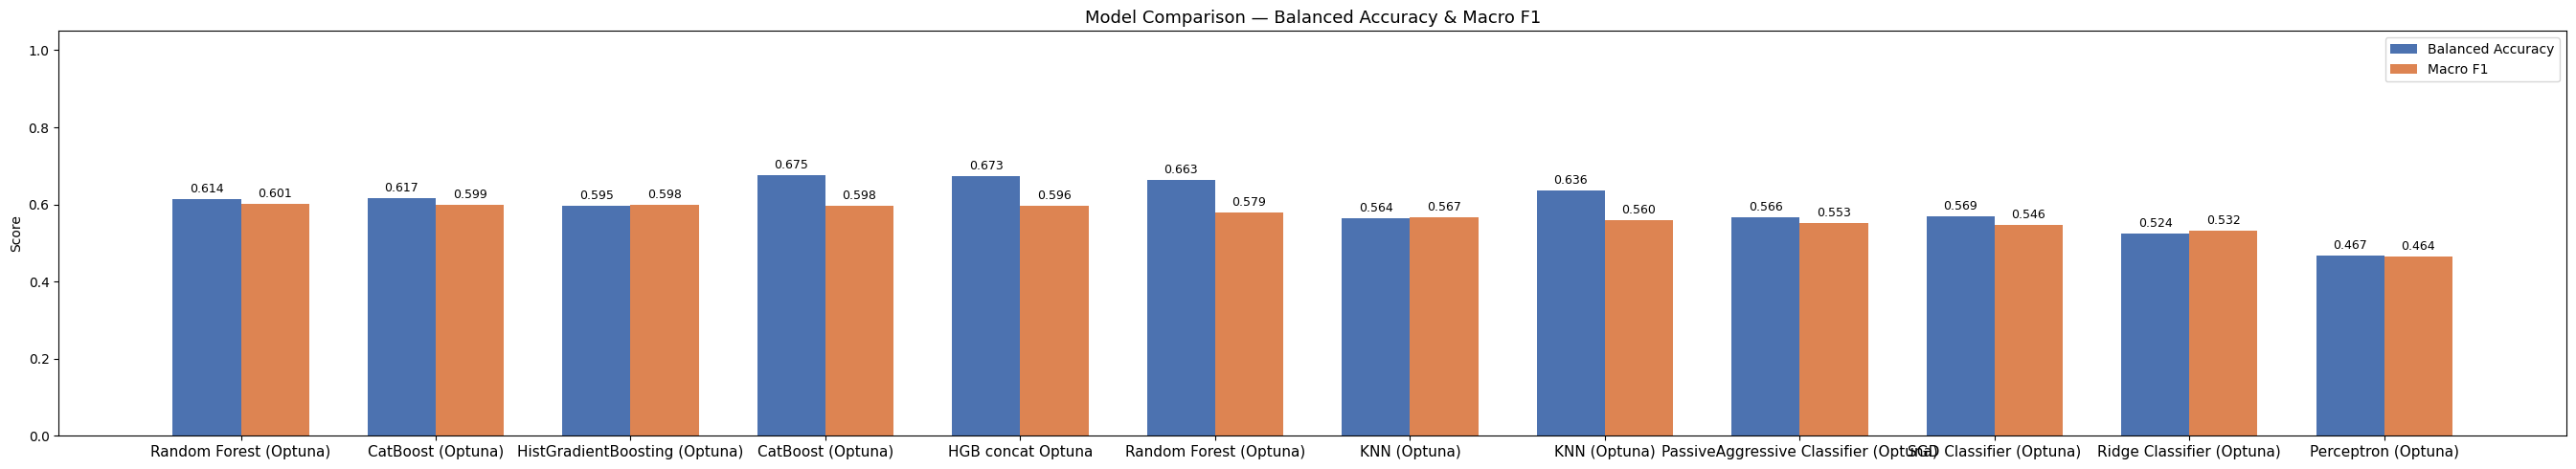


🏆 Best model by Macro F1: Random Forest (Optuna)


In [61]:
results_recife = pd.DataFrame(results).sort_values('macro_f1', ascending=False)
results_recife = results_recife.set_index('model')
print(results_recife.to_string())

fig, ax = plt.subplots(figsize=(27, 5))
x = np.arange(len(results_recife))
width = 0.35

bars1 = ax.bar(x - width/2, results_recife['balanced_acc'], width,
               label='Balanced Accuracy', color='#4C72B0')
bars2 = ax.bar(x + width/2, results_recife['macro_f1'], width,
               label='Macro F1', color='#DD8452')

ax.set_xticks(x)
ax.set_xticklabels(results_recife.index, fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Model Comparison — Balanced Accuracy & Macro F1', fontsize=13)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

best = results_recife['macro_f1'].idxmax()
print(f'\n🏆 Best model by Macro F1: {best}')

## 9. Feature Importance (CatBoost & Random Forest)

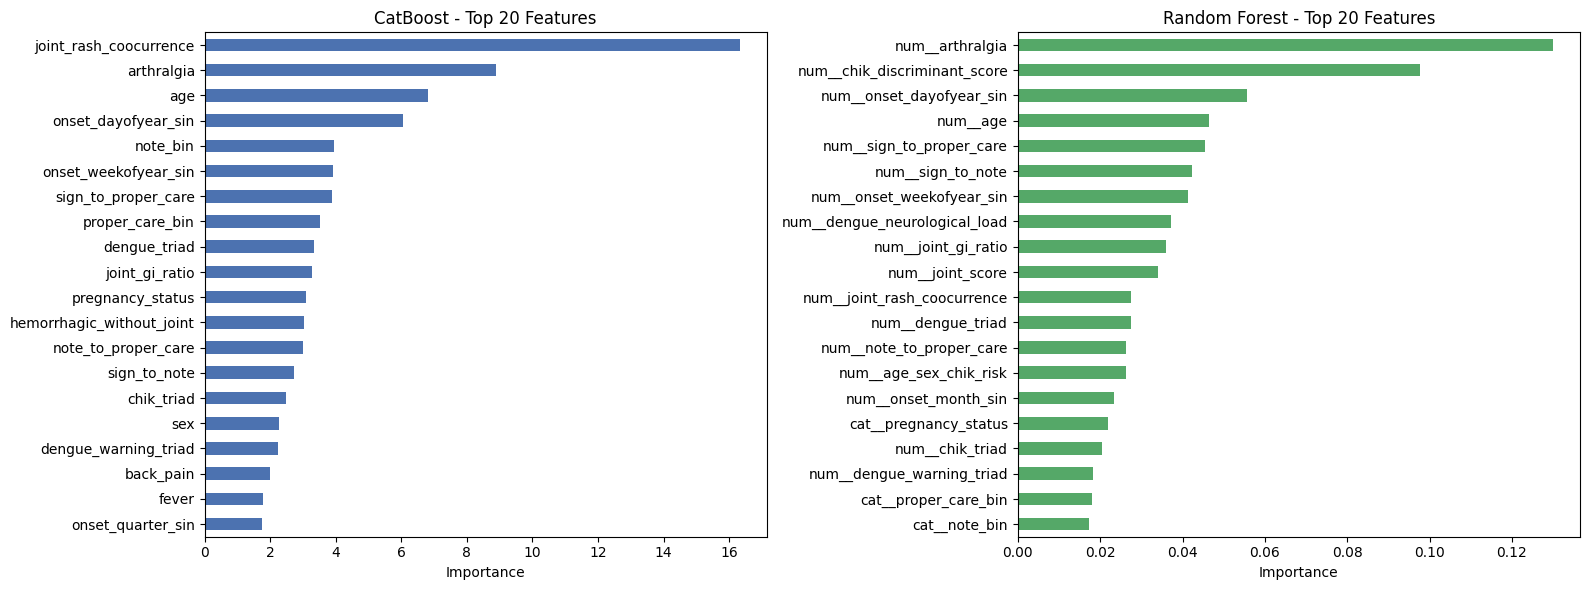

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CatBoost feature importance
if 'catboost_best' in globals():
    cb_fi = pd.Series(
        catboost_best.get_feature_importance(),
        index=X_train_cb.columns
    ).sort_values(ascending=False).head(20)

    cb_fi.plot(kind='barh', ax=axes[0], color='#4C72B0')
    axes[0].invert_yaxis()
    axes[0].set_title('CatBoost - Top 20 Features', fontsize=12)
    axes[0].set_xlabel('Importance')
else:
    axes[0].text(0.5, 0.5, 'Run CatBoost first', ha='center', va='center')
    axes[0].set_axis_off()

# Random Forest feature importance
if 'rf_best' in globals():
    rf_feature_names = rf_best.named_steps['preprocessor'].get_feature_names_out()
    rf_fi = pd.Series(
        rf_best.named_steps['classifier'].feature_importances_,
        index=rf_feature_names
    ).sort_values(ascending=False).head(20)

    rf_fi.plot(kind='barh', ax=axes[1], color='#55A868')
    axes[1].invert_yaxis()
    axes[1].set_title('Random Forest - Top 20 Features', fontsize=12)
    axes[1].set_xlabel('Importance')
else:
    axes[1].text(0.5, 0.5, 'Run Random Forest first', ha='center', va='center')
    axes[1].set_axis_off()

plt.tight_layout()
plt.show()


## Conclusions
### 1. This is not simply a linear-problem (or at least the overall dataset).
Using Tree-based algorithm would suit better.
Unless we can divide the dataset into a linear subcategory, a multi-polynomial or conditional subcategory, using **XGBoost**, **HistGradientBoosting** and **CatBoost** would be the best.

### 2. race priority problem?
Since we are Yellow-skinned, race really affects the prediction for Vietnamese people. Really consider dropping it.

### 3. 